In [ ]:
development = True

In [ ]:
import os
os.chdir("./content")

In [ ]:
import time
inicio_notebook = time.time()

### Instalación de requerimientos e importación de bibliotecas

In [ ]:
%%writefile requirements.txt
contextily
gdown
pandas
geopandas
matplotlib
contextily
folium
polars
fastexcel

Overwriting requirements.txt


In [ ]:
%pip install -r requirements.txt
import os
import gdown
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point


import matplotlib.pyplot as plt
import contextily as ctx
import folium
import re

import polars as pl
import gc

from IPython.display import display

import zipfile
import glob
import shutil



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#@title Operaciones de carpeta

#Definición de carpeta de destino para CSV operación del árbol de directorios

# Definir la carpeta y el archivo de destino
output_dir = "./content/csv"

# Crear la carpeta si no existe
os.makedirs(output_dir, exist_ok=True)

# Se cambia a la carpeta de descaga de CSV
os.chdir(output_dir)

In [ ]:
#@title Fn para descarga de archivos
def descargar_archivos_desde_drive2(dict_base, dict_bk):
    """
    Descarga archivos de Google Drive utilizando un diccionario base.
    Si la descarga de un archivo falla, intenta descargarlo desde un diccionario de backup.
    Evita la descarga si el archivo ya existe localmente.

    Args:
        dict_base (dict): Diccionario principal con {nombre_archivo: id_drive}.
        dict_bk (dict): Diccionario de respaldo con {nombre_archivo: id_drive}.
    """
    for nombre_archivo, file_id_base in dict_base.items():

        # 1. Verificar si el archivo ya existe localmente
        if os.path.exists(nombre_archivo):
            print(f"El archivo '{nombre_archivo}' ya existe localmente. Se omite la descarga.")
            continue

        # 2. Intentar la descarga con el ID del diccionario base
        url_base = f'https://drive.google.com/uc?id={file_id_base}'
        print(f"\n[Base] Intentando descargar '{nombre_archivo}'...")

        try:
            gdown.download(url_base, output=nombre_archivo, quiet=False)
            print(f"¡Éxito! '{nombre_archivo}' descargado desde el servidor base.")

        except Exception as e_base:
            print(f"Error al descargar desde el servidor base: {e_base}")

            # 3. Plan de contingencia: Intentar con el diccionario de backup
            if nombre_archivo in dict_bk:
                file_id_bk = dict_bk[nombre_archivo]
                url_bk = f'https://drive.google.com/uc?id={file_id_bk}'
                print(f"[Backup] Intentando descarga de respaldo para '{nombre_archivo}'...")

                try:
                    gdown.download(url_bk, output=nombre_archivo, quiet=False)
                    print(f"¡Éxito! '{nombre_archivo}' descargado desde el servidor de backup.")
                except Exception as e_bk:
                    print(f"Fallo definitivo: No se pudo descargar '{nombre_archivo}' de ninguna fuente. Error: {e_bk}")
            else:
                print(f"Fallo definitivo: '{nombre_archivo}' no se encuentra en el diccionario de backup.")

In [ ]:
#@title Fn Validar caracteres
def cargar_y_validar_utf8(path_archivo):
    registros_con_error = []
    with open(path_archivo, "rb") as f:
        for numero_linea, linea_binaria in enumerate(f, start=1):
            try:
                linea_binaria.decode("utf-8")
            except UnicodeDecodeError as e:
                registros_con_error.append({
                    "linea": numero_linea,
                    "error": str(e),
                    "contenido_binario": linea_binaria
                })
                break # Agregado por optimización: si ya falló la codificación, no hace falta leer todo el archivo en este punto.

    if registros_con_error:
        print(f"\n❌ [ERROR DE ENCODING DETECTADO EN: {os.path.basename(path_archivo)}]")
        for err in registros_con_error[:1]: # Muestra solo el primer error en consola para no ensuciar el output
            contenido_legible = err["contenido_binario"].decode("utf-8", errors="replace").strip()
            print(f"📍 Línea {err['linea']}: [Bytes Crudos]: {err['contenido_binario']}")
        raise ValueError("El dataset contiene caracteres ajenos al encoding UTF-8.")
    gc.collect()


In [ ]:
#@title Fn: Validar codificación de los CSVs

def procesar_lote_datasets(lista_archivos):
    """
    Itera sobre una lista de archivos CSV, valida su codificación y los carga.
    Si un archivo falla, registra el error y continúa con el siguiente.
    Al final, imprime un reporte detallado.
    """
    dataframes_cargados = {}
    errores_obtenidos = []

    print(f"🚀 Iniciando la validación y carga de {len(lista_archivos)} archivos...\n")

    for path_archivo in lista_archivos:
        nombre_archivo = os.path.basename(path_archivo)
        print(f"🔄 Procesando: {nombre_archivo}...")

        try:
            # Intentamos llamar a tu función de validación y carga
            df_resultado = cargar_y_validar_utf8(path_archivo)

            # Si tiene éxito, lo guardamos en un diccionario usando el nombre del archivo como clave
            dataframes_cargados[nombre_archivo] = df_resultado
            print(f"✅ {nombre_archivo} cargado correctamente.\n")

        except Exception as e:
            # Captura cualquier error (el ValueError de codificación, FileNotFoundError, ComputeError de Polars, etc.)
            errores_obtenidos.append({
                "archivo": nombre_archivo,
                "error_detalle": str(e)
            })
            print(f"⚠️ {nombre_archivo} falló. Saltando al siguiente archivo...\n")

    # ==========================================
    # REPORTE FINAL AL TERMINAR LA ITERACIÓN
    # ==========================================
    print("=" * 60)
    print("📊 RESUMEN FINAL DEL PROCESAMIENTO")
    print("=" * 60)
    print(f"✔️ Archivos cargados con éxito: {len(dataframes_cargados)}")
    print(f"❌ Archivos con errores: {len(errores_obtenidos)}")
    print("-" * 60)

    if errores_obtenidos:
        print("\n📝 DETALLE DE ERRORES ENCONTRADOS:")
        for idx, err in enumerate(errores_obtenidos, start=1):
            print(f"\n{idx}. Archivo: {err['archivo']}")
            print(f"   Error: {err['error_detalle']}")
    else:
        print("\n🎉 ¡Todos los archivos se procesaron y cargaron sin inconvenientes!")

    print("=" * 60)

    # La función devuelve el diccionario con los dataframes que SÍ se pudieron cargar

    return dataframes_cargados

In [ ]:
#@title Explode de los datos geograficos dentro de un registro

def explotar_wkt(df):
    # 1. Copiamos el dataframe para no modificar el original
    df_new = df.copy()

    # 2. Convertimos el string en una lista dividiendo por la coma
    df_new['wkt'] = df_new['wkt'].str.split(',')

    # 3. "Explotamos" la columna wkt
    df_new = df_new.explode('wkt')

    # 4. (Opcional) Limpiar espacios en blanco si existieran
    df_new['wkt'] = df_new['wkt'].str.strip()

    # 5. Resetear el índice para que sea continuo
    df_new = df_new.reset_index(drop=True)

    return df_new

In [ ]:
#@title Limpieza de coordenadas en formato WKT

def limpiar_coordenadas(wkt_string):
    # 1. Quitamos la palabra MULTILINESTRING (sin importar mayúsculas/minúsculas)
    # y eliminamos todos los paréntesis de la cadena.
    paso_1 = re.sub(r'MULTILINESTRING', '', wkt_string, flags=re.IGNORECASE)

    # 2. Limpiamos los paréntesis y espacios sobrantes en los extremos
    resultado = paso_1.replace('(', '').replace(')', '').strip()

    return resultado

# --- Ejemplo de uso ---
raw_data = "MULTILINESTRING ((-58.4521256031295 -34.566215242404,-58.4516295768312 -34.5664769668698,-58.4490265638751 -34.5678793135606,-58.4446681474258 -34.5700123091016))"

coordenadas_limpias = limpiar_coordenadas(raw_data)

print("Resultado:")
print(coordenadas_limpias)

Resultado:
-58.4521256031295 -34.566215242404,-58.4516295768312 -34.5664769668698,-58.4490265638751 -34.5678793135606,-58.4446681474258 -34.5700123091016


### Archivos 2014-2021

In [ ]:
#@title Diccionario de fuentes
dict_datasets_base = {

    'lineas-de-subte.csv': '1sWI3jP6f9VDJ-IE1EI1lkc8rkxooP3b7',
    'estaciones-accesibles.csv': '1V6Cjhf2QU_gcig6HT5EvXhk0n2Egerqr',
    'registro-historico-del-precio-del-boleto.csv': '1yETNbct23DLqYoN7ti6hNV3RdKErwMYI',
    'registro-historico-del-precio-del-boleto.xlsx': '1mY28zAPaI79Pt-OLoNSAhIxnCtflpmKU',
    'viajes_anual.csv': '1PEAW6Vik2k-J7k9C6gxNtl_2df636Q41',
    'historico_2014.csv': '1CyWPBgfAYRBcYvQO7U7cRlAoQbGWoosP',
    'historico_2015.csv': '1g7LpNJFqNcqDmgaGc81MMgV3VfrD6Ah6',
    'historico_2016.csv': '1QqOb3oLoMs014d2YBYw4_e8ww4jo-JX1',
    'historico_2017.csv': '1G7noINplTWyt2g9xRrS7l0BKgFOW05hv',
    'historico_2018.csv': '11WgJxZsC4zUURSlCUBEQKXCQK5RLkRNZ',
    'historico_2019.csv': '1DVgvubSgYCTPQCfA4zj5eiH_ni136o9A',
    'historico_2020.csv': '1hlfAVsJS20InzvIkUXT4t5_nOgd2m1NW',
    'historico_2021.csv': '1hW4qHioTzrXlDnBfWextpMQpar0kmL03'
}

dict_datasets_bk = {
    'lineas-de-subte.csv': '19DoKYs2KUBPENiXyPu9mj2qpngxgUxPD',
    'estaciones-accesibles.csv': '1YJ1Oa4ALUEpZ4mF8AeIWzy564bgcyXvV',
    'registro-historico-del-precio-del-boleto.csv': '1EE2rCerAGd585DO6qYIAX4O7O_QT5y5P',
    'registro-historico-del-precio-del-boleto.xlsx': '1EjW-d3NLb2sXgkiUlOx4qWn4tUlJs0c6',
    'viajes_anual.csv': '1HmXi6DDkfONEEkc_SNzmPgViUibroklX',
    'historico_2014.csv': '1glREzvff9Xy7QiRcQFbPwmLa7QtKdC8M',
    'historico_2015.csv': '1ubs3j1V-PTRbfEbn_D2x5OxBU0H7QIqt',
    'historico_2016.csv': '1PYDajEAWBBXK8Cb6R62al2dxpGdbuqtX',
    'historico_2017.csv': '1LPBerWrFf-wroVkcF1mcYyd-7rvwUu99',
    'historico_2018.csv': '17CKtd2ee9Rq9L8koSVtoHDwL1RdOWEWO',
    'historico_2019.csv': '1V4rfpMFFjnSOz8RQO5sgGDWkXx19C8Q5',
    'historico_2020.csv': '1_uCE3d_VMcbQHr39kKmBqtVyBNuddrFT',
    'historico_2021.csv': '1ptlXJ6Ky3cw89gBLmRsiTkf4P5G2c7Z-'
}

In [ ]:
#@title Descarga de archivos

descargar_archivos_desde_drive2(dict_datasets_base, dict_datasets_bk)

El archivo 'lineas-de-subte.csv' ya existe localmente. Se omite la descarga.
El archivo 'estaciones-accesibles.csv' ya existe localmente. Se omite la descarga.
El archivo 'registro-historico-del-precio-del-boleto.csv' ya existe localmente. Se omite la descarga.
El archivo 'registro-historico-del-precio-del-boleto.xlsx' ya existe localmente. Se omite la descarga.
El archivo 'viajes_anual.csv' ya existe localmente. Se omite la descarga.
El archivo 'historico_2014.csv' ya existe localmente. Se omite la descarga.
El archivo 'historico_2015.csv' ya existe localmente. Se omite la descarga.
El archivo 'historico_2016.csv' ya existe localmente. Se omite la descarga.
El archivo 'historico_2017.csv' ya existe localmente. Se omite la descarga.
El archivo 'historico_2018.csv' ya existe localmente. Se omite la descarga.
El archivo 'historico_2019.csv' ya existe localmente. Se omite la descarga.
El archivo 'historico_2020.csv' ya existe localmente. Se omite la descarga.
El archivo 'historico_2021.cs

### Load: Estaciones datasets

In [ ]:
# Se cargan archivos en dataframes de pandas
# Se agrega el encoding latin 1 para evitar errores

lineas_subte_df = pd.read_csv('lineas-de-subte.csv', encoding='latin-1')
estaciones_accesibles_df = pd.read_csv('estaciones-accesibles.csv', encoding='latin-1')
registro_historico_del_precio_del_boleto_df = pd.read_csv('registro-historico-del-precio-del-boleto.csv', encoding='latin-1')
#registro_historico_del_precio_del_boleto_excel_df = pd.read_excel('registro-historico-del-precio-del-boleto.xlsx')
viajes_anual_df = pd.read_csv('viajes_anual.csv', encoding='latin-1')

### EDA: Estaciones

In [ ]:
print("lineas_subte - Column names ", lineas_subte_df.columns.tolist())
display(lineas_subte_df.head())

print ('\n\n---------------------\n\n')

print("estaciones_accesibles - Column names:", estaciones_accesibles_df.columns.tolist())
display(estaciones_accesibles_df.head())

lineas_subte - Column names  ['wkt', 'id', 'lineasub']


,wkt,id,lineasub
0,MULTILINESTRING ((-58.4521256031295 -34.566215...,1,LINEA D
1,MULTILINESTRING ((-58.4564891346516 -34.562309...,2,LINEA D
2,MULTILINESTRING ((-58.4446681474258 -34.570012...,3,LINEA D
3,MULTILINESTRING ((-58.4350135329444 -34.575178...,4,LINEA D
4,MULTILINESTRING ((-58.4257114410852 -34.578422...,5,LINEA D




---------------------


estaciones_accesibles - Column names: ['long', 'lat', 'linea', 'estacion', 'escaleras_mecanicas', 'ascensores']


,long,lat,linea,estacion,escaleras_mecanicas,ascensores
0,-58.436429,-34.618280,A,ACOYTE,2,2
1,-58.456710,-34.626667,A,CARABOBO,3,3
2,-58.421816,-34.611770,A,CASTRO BARROS,1,1
3,-58.392669,-34.609226,A,CONGRESO,2,2
4,-58.382232,-34.609100,A,LIMA,1,0


Se observa que existen diferencias en la nomenclatura utilizada en estos dos dataframes, motivo por el cual se hace necesario estandarizar encabezados. También se observa que el datos de "linea" se presenta en dos formatos diferentes.

También se observa que en lineas_subte hay registros que continen listas de datos lo cual hara necesario aplicar transformaciones para manejar los datos de manera atómica o individualizada

#### Evaluación de ceros

In [ ]:
# Definir la condición (máscara booleana)
condicion = (estaciones_accesibles_df['escaleras_mecanicas'] == 0) & (estaciones_accesibles_df['ascensores'] == 0)

# Filtrar el DataFrame y usar display() para una visualización enriquecida en Colab
display(estaciones_accesibles_df[condicion])

,long,lat,linea,estacion,escaleras_mecanicas,ascensores


Se observa que no hay estaciones listadas como estaciones accesibles que posean 0 escaleras mecánicas y 0 ascensores, lo cual resulta una apreciación correcta.

#### Estandarización de cabeceras de LINEAS_SUBTE_DF

In [ ]:
#@title Estandarización de cabeceras de LINEAS_SUBTE_DF

print("Nombre de columnas original")
print("Column names:", lineas_subte_df.columns.tolist())

# cambiar nombre de columna 'lineasub' a 'linea' en dataframe lineas_subte_df
lineas_subte_df.rename(columns={'lineasub': 'linea'}, inplace=True)

# en lineas_subte_df eliminar de los registros de columna 'linea' la cadena "LINEA "
lineas_subte_df['linea'] = lineas_subte_df['linea'].str.replace('LINEA ', '')

# en lineas_subte_df eliminar de los registros de columna 'wkt' la cadena MULTILINESTRING "

#lineas_subte_df[['long', 'lat']] = lineas_subte_df['wkt'].str.split(' ', expand=True).astype(float)
#lineas_subte_df['long'] = lineas_subte_df['wkt'].str.replace(')', '')
#lineas_subte_df['lat'] = lineas_subte_df['wkt'].str.replace(')', '')

print("LINEAS_SUBTE")
display(lineas_subte_df.head())

Nombre de columnas original
Column names: ['wkt', 'id', 'lineasub']
LINEAS_SUBTE


,wkt,id,linea
0,MULTILINESTRING ((-58.4521256031295 -34.566215...,1,D
1,MULTILINESTRING ((-58.4564891346516 -34.562309...,2,D
2,MULTILINESTRING ((-58.4446681474258 -34.570012...,3,D
3,MULTILINESTRING ((-58.4350135329444 -34.575178...,4,D
4,MULTILINESTRING ((-58.4257114410852 -34.578422...,5,D


#### Estandarizacion de geo-coordenadas

In [ ]:
lineas_subte_df['wkt'] = lineas_subte_df['wkt'].str.replace('MULTILINESTRING ', '')
lineas_subte_df['wkt'] = lineas_subte_df['wkt'].str.replace('(', '')
lineas_subte_df['wkt'] = lineas_subte_df['wkt'].str.replace(')', '')

# usar la funcion explotar_wkt para separar todas las coordenadas en columna wkt
lineas_subte_wktexploded_df = explotar_wkt(lineas_subte_df)
lineas_subte_wktexploded_df[['long', 'lat']] = lineas_subte_wktexploded_df['wkt'].str.split(' ', expand=True).astype(float)

pd.set_option('display.max_rows', 200)
display(lineas_subte_wktexploded_df.head(20))

,wkt,id,linea,long,lat
0,-58.4521256031295 -34.566215242404,1,D,-58.452126,-34.566215
1,-58.4516295768312 -34.5664769668698,1,D,-58.451630,-34.566477
2,-58.4490265638751 -34.5678793135606,1,D,-58.449027,-34.567879
3,-58.4446681474258 -34.5700123091016,1,D,-58.444668,-34.570012
4,-58.4564891346516 -34.562309088005,2,D,-58.456489,-34.562309
5,-58.4552832314547 -34.5637017066676,2,D,-58.455283,-34.563702
6,-58.4542954219076 -34.564879858685,2,D,-58.454295,-34.564880
7,-58.4540199050523 -34.5651812402078,2,D,-58.454020,-34.565181
8,-58.4537653834182 -34.5653812458169,2,D,-58.453765,-34.565381
9,-58.4534087763102 -34.565570332104,2,D,-58.453409,-34.565570


#### Exploración y evaluación de duplicados

In [ ]:
# Display de duplicados de la columna estacion_accesibles_df[estacion]
estaciones_repetidas_df = estaciones_accesibles_df[estaciones_accesibles_df.duplicated(subset=['estacion'], keep=False)]
display(estaciones_repetidas_df)

,long,lat,linea,estacion,escaleras_mecanicas,ascensores
16,-58.392314,-34.604420,B,CALLAO,5,3
17,-58.393125,-34.599640,B,CALLAO,5,3
30,-58.405399,-34.604581,B,PUEYRREDON,5,0
31,-58.402395,-34.594426,B,PUEYRREDON,5,0
37,-58.380174,-34.618126,C,INDEPENDENCIA,2,0
38,-58.381535,-34.617937,C,INDEPENDENCIA,2,0
41,-58.374018,-34.591194,C,RETIRO,2,0
42,-58.376632,-34.591901,C,RETIRO,2,0
48,-58.392314,-34.604420,D,CALLAO,1,1
49,-58.393125,-34.599640,D,CALLAO,1,1


#### Creación del GeoDataFrame #1

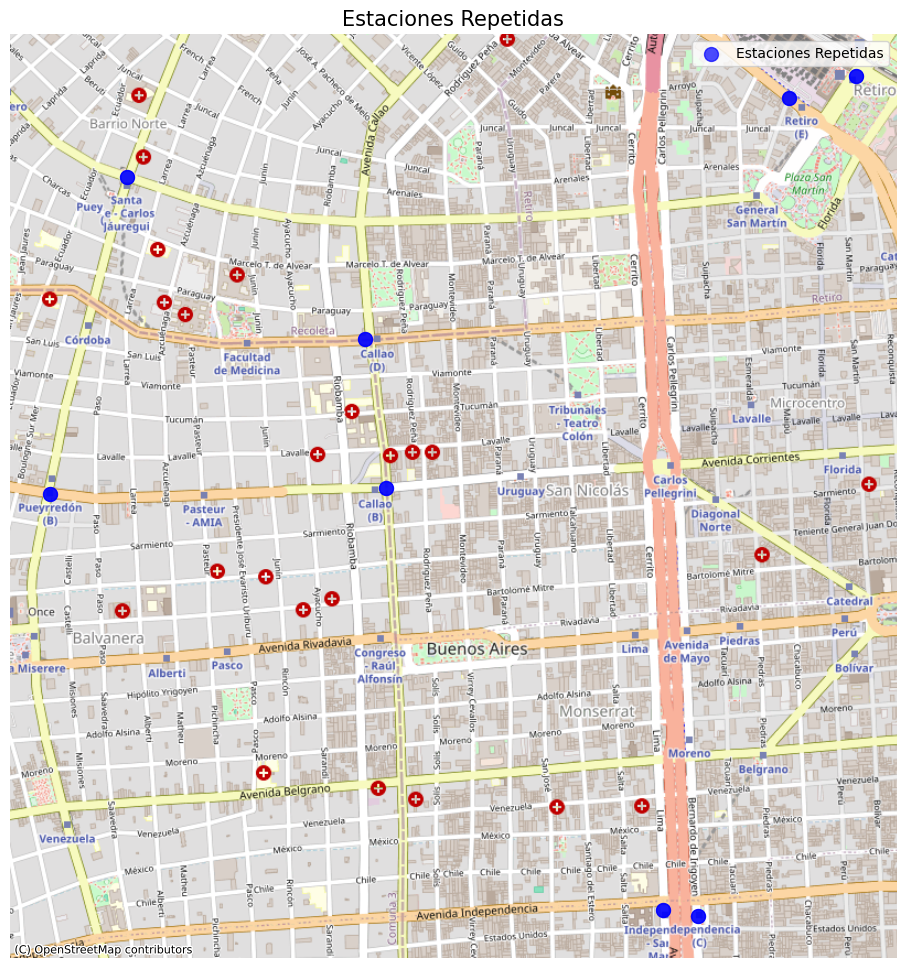

In [ ]:
# 1. Crear el GeoDataFrame (Asegúrate de definir el CRS inicial como WGS84 - EPSG:4326)
estaciones_repetidas_gdf = gpd.GeoDataFrame(
    estaciones_repetidas_df,
    geometry=gpd.points_from_xy(estaciones_repetidas_df.long, estaciones_repetidas_df.lat),
    crs="EPSG:4326"
)

# 2. Transformar a Web Mercator (EPSG:3857)
# Es el sistema que usan los mapas web (Google Maps, OSM) para que la imagen no se deforme
estaciones_repetidas_gdf = estaciones_repetidas_gdf.to_crs(epsg=3857)

# 3. Graficar
fig, ax = plt.subplots(figsize=(12, 12))

# Dibujar los puntos
estaciones_repetidas_gdf.plot(
    ax=ax,
    marker='o',
    color='blue',
    markersize=100,
    alpha=0.7,
    edgecolor='blue',
    label='Estaciones Repetidas'
)


# Agregar el mapa de fondo (Calles de Buenos Aires)
# Tip: 'source' puede ser ctx.providers.CartoDB.Positron para un mapa claro
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Ajustes estéticos
ax.set_title("Estaciones Repetidas", fontsize=15)
ax.set_axis_off()
plt.legend()
plt.show()

#eestaciones_repetidas_gdf.plot(figsize=(10, 10))

Se observa que varias de las estaciones repetidas poseen la misma ubicación geográfica pero el dataset se refiere a estaciones diferentes.

**Acciones tomadas**
Se procede a investigar cuales son los registros correctos analizando la ubicación geográfica informada de cada registro y las características informadas de cantidad de ascensores y escaleras contrastando con la informacion disponible en el sitio web https://emova.com.ar/index.php/accesibilidad/y . En consecuencia se eliminan los incorrectos del dataframe según se detalla a continuación.

#### Tratamiento de duplicados

In [ ]:
# Elimina los index 17 y 48 de estaciones_accesibles_df (Callao)
estaciones_accesibles_clean1_df = estaciones_accesibles_df.drop([17, 48])

# Elimina los index 31 y 59 de estaciones_accesibles_df (Pueyrredon)
estaciones_accesibles_clean1_df = estaciones_accesibles_clean1_df.drop([31, 59])

# Elimina los index 38, 70 de estaciones_accesibles_df (Independencia)
estaciones_accesibles_clean1_df = estaciones_accesibles_clean1_df.drop([38, 70])

# Elimina los index 42 y 76 de estaciones_accesibles_df (Retiro)
estaciones_accesibles_clean1_df = estaciones_accesibles_clean1_df.drop([42, 76])

print("ESTACIONES ACCESIBLES SIN DUPLICADOS")
display(estaciones_accesibles_clean1_df)

ESTACIONES ACCESIBLES SIN DUPLICADOS


,long,lat,linea,estacion,escaleras_mecanicas,ascensores
0,-58.436429,-34.618280,A,ACOYTE,2,2
1,-58.456710,-34.626667,A,CARABOBO,3,3
2,-58.421816,-34.611770,A,CASTRO BARROS,1,1
3,-58.392669,-34.609226,A,CONGRESO,2,2
4,-58.382232,-34.609100,A,LIMA,1,0
5,-58.415186,-34.610782,A,LORIA,1,1
6,-58.374268,-34.608559,A,PERU,2,2
7,-58.379085,-34.608882,A,PIEDRAS,1,0
8,-58.370968,-34.608810,A,PLAZA DE MAYO,0,1
9,-58.406707,-34.609817,A,PLAZA MISERERE,6,0


#### Creacion de Geodataframe #2

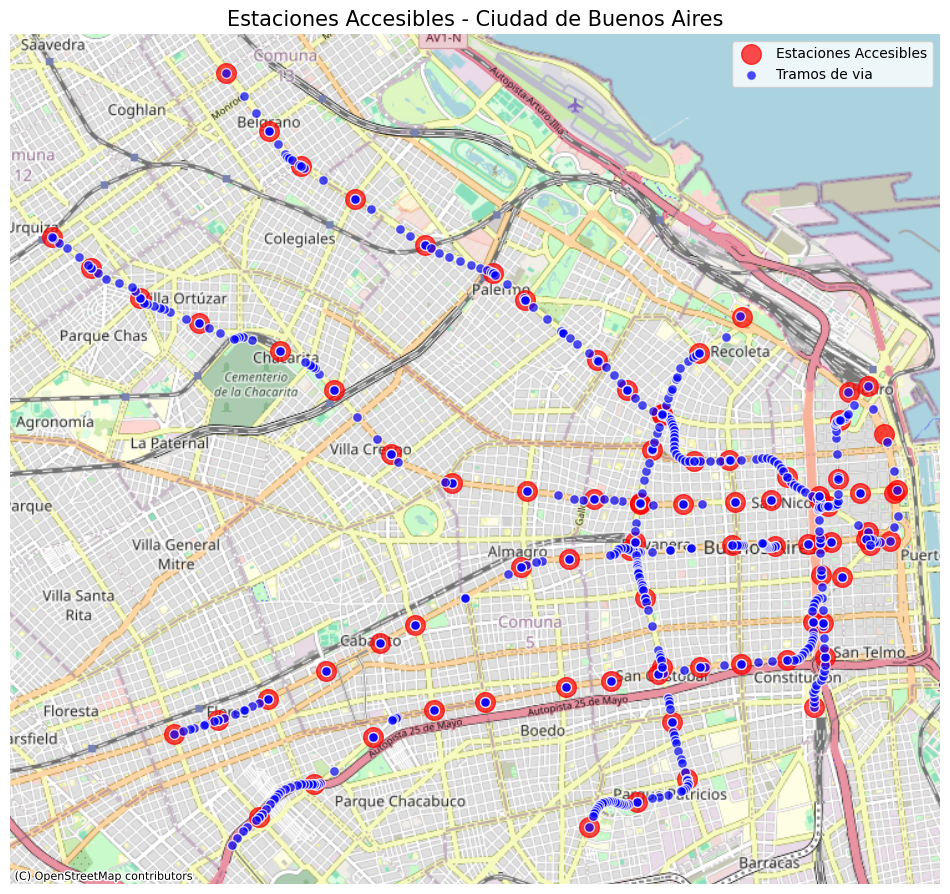

In [ ]:
# 1. Crear el GeoDataFrame (Asegúrate de definir el CRS inicial como WGS84 - EPSG:4326)
estaciones_accesibles_gdf = gpd.GeoDataFrame(
    estaciones_accesibles_clean1_df,
    geometry=gpd.points_from_xy(estaciones_accesibles_clean1_df.long, estaciones_accesibles_clean1_df.lat),
    crs="EPSG:4326"
)

lineas_subte_gdf = gpd.GeoDataFrame(
    lineas_subte_wktexploded_df,
    geometry=gpd.points_from_xy(lineas_subte_wktexploded_df.long, lineas_subte_wktexploded_df.lat),
    crs="EPSG:4326"
)

# 2. Transformar a Web Mercator (EPSG:3857)
# Es el sistema que usan los mapas web (Google Maps, OSM) para que la imagen no se deforme
estaciones_accesibles_gdf = estaciones_accesibles_gdf.to_crs(epsg=3857)
lineas_subte_gdf = lineas_subte_gdf.to_crs(epsg=3857)


# 3. Graficar
fig, ax = plt.subplots(figsize=(12, 12))

# Dibujar los puntos
estaciones_accesibles_gdf.plot(
    ax=ax,
    marker='o',
    color='red',
    markersize=200,
    alpha=0.7,
    edgecolor='red',
    label='Estaciones Accesibles'
)

lineas_subte_gdf.plot(
    ax=ax,
    marker='o',
    color='blue',
    markersize=50,
    alpha=0.7,
    edgecolor='white',
    label='Tramos de via'
)

# Agregar el mapa de fondo (Calles de Buenos Aires)
# Tip: 'source' puede ser ctx.providers.CartoDB.Positron para un mapa claro
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Ajustes estéticos
ax.set_title("Estaciones Accesibles - Ciudad de Buenos Aires", fontsize=15)
ax.set_axis_off()
plt.legend()
plt.show()

#estaciones_accesibles_gdf.plot(figsize=(10, 10))




### XXXXXXXXXXXX

In [ ]:
#@title NO SABEMOS QUE HACE ESTO PERO LO DEJAMOS POR LAS DUDAS

# 1. Aseguramos el CRS (Sistemas de Coordenadas)
if estaciones_accesibles_gdf.crs is None:
    estaciones_accesibles_gdf.set_crs(epsg=4326, inplace=True)
if lineas_subte_gdf.crs is None:
    lineas_subte_gdf.set_crs(epsg=4326, inplace=True)

# 2. Proyectamos a metros para cálculos de distancia precisos
rojas_m = estaciones_accesibles_gdf.to_crs(epsg=3857)
azules_m = lineas_subte_gdf.to_crs(epsg=3857)

# 3. Iteramos por 'línea' de subte para asegurar que el ID pertenezca a la red correcta
resultados_por_linea = []

for linea in rojas_m['linea'].unique():
    # Filtramos ambos dataframes por la línea actual (A, B, C, etc.)
    rojas_sub = rojas_m[rojas_m['linea'] == linea]
    azules_sub = azules_m[azules_m['linea'] == linea]

    # Si hay puntos azules para esa línea, buscamos el más cercano
    if not azules_sub.empty:
        match = gpd.sjoin_nearest(
            rojas_sub,
            azules_sub[['id', 'geometry']],
            how='left',
            distance_col="distancia_metros"
        )
        resultados_por_linea.append(match)


# 4. Consolidamos todos los resultados en un solo DataFrame
resultado_final = pd.concat(resultados_por_linea)

# 5. Limpiamos duplicados (aseguramos 1 ID por cada Estación/Línea)
# Ordenamos por distancia para que al borrar duplicados quede siempre el más cercano
resultado_final = resultado_final.sort_values('distancia_metros').drop_duplicates(subset=['estacion', 'linea'])

# 6. Mostramos las primeras 50 líneas del resultado
print(resultado_final[['estacion', 'linea', 'id', 'distancia_metros']].head(100))

                estacion linea  id  distancia_metros
92             VENEZUELA     H  67      0.000000e+00
86          HUMBERTO 1Â°     H  67      0.000000e+00
85            HOSPITALES     H  73      0.000000e+00
88             LAS HERAS     H  80      0.000000e+00
83            CORRIENTES     H  71      0.000000e+00
90      PARQUE PATRICIOS     H  72      0.000000e+00
81               CASEROS     H  68      9.313226e-10
82               CORDOBA     H  79      9.313226e-10
87                INCLAN     H  66      9.313226e-10
91              SANTA FE     H  80      9.313226e-10
89                  ONCE     H  65      1.862645e-09
14           SAN PEDRITO     A  77      9.355593e-06
57               PALERMO     D   4      1.569255e-05
6                   PERU     A  60      1.650395e-05
35          CONSTITUCION     C  13      2.028238e-05
32              TRONADOR     B  64      3.541226e-05
5                  LORIA     A  46      3.826946e-05
3               CONGRESO     A  23      4.0672

#### Insercion de id a dataframe estaciones_accesibles_gdf

In [ ]:
# 1. Creamos la tabla de mapeo (solo con lo que necesitamos)
df_mapeo_id = resultado_final[['estacion', 'linea', 'id']].drop_duplicates()

# 2. Hacemos el merge en el nuevo DataFrame
estaciones_accesibles_gdf_merged = estaciones_accesibles_gdf.merge(
    df_mapeo_id,
    on=['estacion', 'linea'],
    how='left'
)

# 3. ELIMINAMOS la columna 'geometry' que se coló en el proceso
if 'geometry' in estaciones_accesibles_gdf_merged.columns:
    # Eliminamos la columna geometry
    estaciones_accesibles_gdf_merged = estaciones_accesibles_gdf_merged.drop(columns=['geometry'])

# 4. Reordenamos para que 'id' sea la primera columna, seguida de todas las originales
columnas_originales = estaciones_accesibles_gdf.columns.tolist()
# Quitamos 'geometry' de la lista de originales por si acaso estaba ahí
columnas_originales = [c for c in columnas_originales if c != 'geometry']

orden_final = ['id'] + columnas_originales
estaciones_accesibles_gdf_merged = estaciones_accesibles_gdf_merged[orden_final]

# cambiar el dato "estacion" del index=12 de staciones_accesibles_gdf_merged a "SaenzP"

# 5. Verificamos el resultado final
print("Resultado final limpio (sin geometry sobrante):")
print(estaciones_accesibles_gdf_merged.head(100))

Resultado final limpio (sin geometry sobrante):
    id       long        lat linea              estacion  escaleras_mecanicas  \
0   49 -58.436429 -34.618280     A                ACOYTE                    2   
1   76 -58.456710 -34.626667     A              CARABOBO                    3   
2   46 -58.421816 -34.611770     A         CASTRO BARROS                    1   
3   23 -58.392669 -34.609226     A              CONGRESO                    2   
4   20 -58.382232 -34.609100     A                  LIMA                    1   
5   46 -58.415186 -34.610782     A                 LORIA                    1   
6   60 -58.374268 -34.608559     A                  PERU                    2   
7   20 -58.379085 -34.608882     A               PIEDRAS                    1   
8   60 -58.370968 -34.608810     A         PLAZA DE MAYO                    0   
9   22 -58.406707 -34.609817     A        PLAZA MISERERE                    6   
10  69 -58.441178 -34.620405     A         PRIMERA JUNTA     

#### Corrección nombre de estaciones

In [ ]:
#@title Corrección de nombres de las estaciones
estaciones_accesibles_gdf_merged.at[12, 'estacion'] = 'SAENZ PENA'
estaciones_accesibles_gdf_merged.at[46, 'estacion'] = 'AGUERO'
estaciones_accesibles_gdf_merged.at[86, 'estacion'] = 'HUMBERTO 1RO'

# Verificamos el resultado final
print("Resultado final limpio (sin geometry sobrante):")
print(estaciones_accesibles_gdf_merged.head(100))

Resultado final limpio (sin geometry sobrante):
      id       long        lat linea              estacion  \
0   49.0 -58.436429 -34.618280     A                ACOYTE   
1   76.0 -58.456710 -34.626667     A              CARABOBO   
2   46.0 -58.421816 -34.611770     A         CASTRO BARROS   
3   23.0 -58.392669 -34.609226     A              CONGRESO   
4   20.0 -58.382232 -34.609100     A                  LIMA   
5   46.0 -58.415186 -34.610782     A                 LORIA   
6   60.0 -58.374268 -34.608559     A                  PERU   
7   20.0 -58.379085 -34.608882     A               PIEDRAS   
8   60.0 -58.370968 -34.608810     A         PLAZA DE MAYO   
9   22.0 -58.406707 -34.609817     A        PLAZA MISERERE   
10  69.0 -58.441178 -34.620405     A         PRIMERA JUNTA   
11  70.0 -58.448648 -34.623529     A                  PUAN   
12  26.0 -58.386777 -34.609413     A            SAENZ PENA   
13  77.0 -58.463541 -34.629087     A    SAN JOSE DE FLORES   
14  77.0 -58.469640 -3

#### Gráfica de mapa interactivo

In [ ]:
# por algun motivo se rompe el mapa interactivo


In [ ]:
#@title Limpieza de datasets utilizados con Pandas y liberación de memoria
del lineas_subte_df
del estaciones_accesibles_df
gc.collect()

XXXXXXXXXX

### Carga de datasets accesorios y configuración global

Los datasets accesorios (líneas, estaciones, precios, viajes) son chicos y se mantienen en memoria todo el tiempo. Se cargan una sola vez.

In [ ]:
#@title Configuración global polars y nulos

null_values = ["", " ", "null", "NULL", "NaN", "NA", "N/A", "-"]

# Config de visualización de Polars (no mutila strings largos)
pl.Config.set_tbl_rows(100)
pl.Config.set_fmt_str_lengths(100)

print('Polars ha sido configurado')

In [ ]:
#@title Carga datasets accesorios

lineas_subte_df = pl.read_csv('lineas-de-subte.csv', encoding='latin-1', null_values=null_values)
estaciones_accesibles_df = pl.read_csv('estaciones-accesibles.csv', encoding='latin-1', null_values=null_values)
registro_historico_del_precio_del_boleto_df = pl.read_csv('registro-historico-del-precio-del-boleto.csv', encoding='latin-1', null_values=null_values)
registro_historico_del_precio_del_boleto_excel_df = pl.read_excel('registro-historico-del-precio-del-boleto.xlsx')
viajes_anual_df = pl.read_csv('viajes_anual.csv', encoding='latin-1', null_values=null_values)

print("Accesorios cargados:")
for n in ["lineas_subte_df","estaciones_accesibles_df","registro_historico_del_precio_del_boleto_df","viajes_anual_df"]:
    print(f"  • {n}: {globals()[n].shape}")


### Exploración de estaciones accesibles sin escaleras mecánicas ni ascensores

In [ ]:
# Exploración de estaciones accesibles sin escaleras mecánicas ni ascensores

# Se filtra usando .filter() y expresiones pl.col
resultado_df = estaciones_accesibles_df.filter(
    (pl.col("escaleras_mecanicas") == 0) & (pl.col("ascensores") == 0)
)

# Lo mostrás directamente (acordate que no hace falta display si es lo último)
resultado_df

### Observaciones

Se observa que no hay estaciones listadas como estaciones accesibles que posean 0 escaleras mecánicas y 0 ascensores, lo cual es correcto.

## Pipeline de procesamiento por año (carga → curación → exportación → liberación)

El dataset de cada año se procesa de forma **aislada**: se carga, se cura, se diagnostica, se exporta a Parquet y se libera la memoria antes de pasar al siguiente. En ningún momento conviven dos años en RAM.

Cada etapa de curación es una función pura (recibe un `DataFrame`, devuelve un `DataFrame`). La función maestra `procesar_anio()` las orquesta e imprime los diagnósticos mientras el año está en memoria.

## EDA Inicial - Archivos 2014-2021

In [ ]:
#@title 2014 visual
historico_2014_df = pd.read_csv('historico_2014.csv', encoding='utf8', nrows=5)
historico_2014_df

In [ ]:
#@title 2015 visual
historico_2015_df = pd.read_csv('historico_2015.csv', encoding='utf8', nrows=5)
historico_2015_df

In [ ]:
#@title 2016 visual
historico_2016_df = pd.read_csv('historico_2016.csv', encoding='utf8', nrows=5)
historico_2016_df

In [ ]:
#@title 2017 visual
historico_2017_df = pd.read_csv('historico_2017.csv', encoding='utf8', nrows=5)
historico_2017_df

In [ ]:
#@title 2018 visual
historico_2018_df = pd.read_csv('historico_2018.csv', encoding='utf8', nrows=5)
historico_2018_df

In [ ]:
#@title 2019 visual
historico_2019_df = pd.read_csv('historico_2019.csv', encoding='utf8', nrows=5)
historico_2019_df

In [ ]:
#@title 2020 visual
historico_2020_df = pd.read_csv('historico_2020.csv', encoding='utf8', nrows=5)
historico_2020_df

In [ ]:
#@title 2021 visual
historico_2021_df = pd.read_csv('historico_2021.csv', encoding='utf8', nrows=5)
historico_2021_df

In [ ]:
#@ Eliminar Dataframes de Pandas de exploración inicial
import gc

if "historico_2014_df" in locals() and historico_2014_df is not None:
    del historico_2014_df

if "historico_2015_df" in locals() and historico_2015_df is not None:
    del historico_2015_df

if "historico_2016_df" in locals() and historico_2016_df is not None:
    del historico_2016_df

if "historico_2017_df" in locals() and historico_2017_df is not None:
    del historico_2017_df

if "historico_2018_df" in locals() and historico_2018_df is not None:
    del historico_2018_df

if "historico_2019_df" in locals() and historico_2019_df is not None:
    del historico_2019_df

if "historico_2020_df" in locals() and historico_2020_df is not None:
    del historico_2020_df

if "historico_2021_df" in locals() and historico_2021_df is not None:
    del historico_2021_df

gc.collect()
print("Dataframes de exploracion inicial borrados - Memoria liberada")

Tras esta exploración inicial se puede observar que los archivos historicos 2014 a 2021 si bien siguen una estructura general homóloga no respetan el mismo orden de columnas ni los nombres de las mismas se encuentran normalizados e incluso utilizan diferentes tipos de separadores (, o ;) por lo que es necesario aplicar transformaciones para resolverlo.

In [ ]:
#@title Caracteres anómalos
archivos = [
    "./historico_2014.csv",
    "./historico_2015.csv",
    "./historico_2016.csv",
    "./historico_2017.csv",
    "./historico_2018.csv",
    "./historico_2019.csv",
    "./historico_2020.csv",
    "./historico_2021.csv"
]

# 2. Ejecutas la función mayor
mis_dataframes = procesar_lote_datasets(archivos)

# 3. Para acceder a cualquier dataframe que se haya cargado bien, usas su nombre:
# if "historico_2016.csv" in mis_dataframes:
#     df_2016 = mis_dataframes["historico_2016.csv"]

#### Creacion de tabla de Estaciones

In [ ]:
#@title Creacion de tabla de Estaciones

archivo_estaciones = "./historico_2017.csv"
columnas_a_conservar = ["ID_ESTACION", "LINEA", "ESTACION"]
ruta_salida = "./estaciones_procesadas.csv"

# Crear el dataframe y procesarlo con Pandas especificando el encoding
df_estaciones_con_id = (
    pd.read_csv(
        archivo_estaciones,
        usecols=columnas_a_conservar,
        encoding="latin-1"  # <-- Esto arregla el error de lectura
    )
    .drop_duplicates()
    .sort_values(by="ID_ESTACION")
)

# Guardar el resultado (aquí sí lo guardamos en utf-8 para que no te vuelva a dar problemas en el futuro)
df_estaciones_con_id.to_csv(ruta_salida, index=False, encoding="utf-8")

print(f"El DataFrame ha sido creado y guardado con éxito en: {ruta_salida}")

## Etapas del pipeline de transformación

In [ ]:
# Constantes del pipeline

COLUMNAS_DESEADAS = [
    "FECHA", "DESDE", "HASTA", "LINEA", "ESTACION","MOLINETE", "PAX_PAGO",
    "PAX_PAGOS", "PAX_PASES_PAGOS",
    "PAX_FREQ", "PAX_FRANQ", "PAX_TOTAL", "TOTAL"
]

#COLUMNAS_DESEADAS = [
#    "FECHA", "DESDE", "HASTA", "LINEA", "ESTACION", "PAX_TOTAL", "TOTAL"
#]


# Carpeta de salida de los parquet (un nivel arriba del cwd ./content/csv -> ./content/parquet)
CARPETA_PARQUET = os.path.abspath(os.path.join(os.getcwd(), "..", "parquet"))
os.makedirs(CARPETA_PARQUET, exist_ok=True)
print(f"Los parquet se exportarán a: {CARPETA_PARQUET}")


In [ ]:
#@title ETAPA 1: Carga selectiva de columnas ---

def cargar_anio(anio: int) -> pl.DataFrame | None:
    """Carga un CSV anual trayendo solo las columnas de interés.
    Maneja los casos especiales: 2021 (separador ';') y 2016/2017 (encoding lossy)."""
    ruta_csv = f"historico_{anio}.csv"
    separador = ";" if anio == 2021 else ","
    encoding = "utf8-lossy" if anio in (2016, 2017) else "utf8"

    try:
        lf = pl.scan_csv(
            ruta_csv,
            null_values=null_values,
            infer_schema_length=0,   # todo como String; casteamos nosotros después
            separator=separador,
            encoding=encoding,
        )
        columnas_reales = lf.collect_schema().names()
        columnas_a_importar = [c for c in columnas_reales if c.upper() in COLUMNAS_DESEADAS]
        df = lf.select(columnas_a_importar).collect()
        print(f"  [carga] {ruta_csv} | sep='{separador}' enc='{encoding}' | "
              f"cols={columnas_a_importar} | shape={df.shape}")
        return df
    except FileNotFoundError:
        print(f"  [carga] No se encontró {ruta_csv} — se omite el año {anio}.")
        return None


In [ ]:
#@title ETAPA 2: Estandarización de nomenclaturas y mayúsculas ---

def estandarizar_columnas(df: pl.DataFrame, anio: int) -> pl.DataFrame:
    """Unifica nombres: PAX_FREQ/PAX_FRANQUICIAS -> PAX_FRANQ, TOTAL -> PAX_TOTAL,
    PAX_PAGO -> PAX_PAGOS (caso 2014), y finalmente todo a MAYÚSCULAS."""
    renombrado = {}
    cols_upper = [c.upper() for c in df.columns]

    for col in df.columns:
        cu = col.upper()
        if cu in ("PAX_FREQ", "PAX_FRANQUICIAS"):
          renombrado[col] = "PAX_FRANQ"
         # TOTAL -> PAX_TOTAL solo si no existe ya PAX_TOTAL (corrige el bug de indentación original)
        elif cu == "TOTAL" and "PAX_TOTAL" not in cols_upper:
            renombrado[col] = "PAX_TOTAL"
        elif cu == "PAX_PAGO":   # caso 2014: singular -> plural
            renombrado[col] = "PAX_PAGOS"

    if renombrado:
        df = df.rename(renombrado)
        print(f"  [nomenclatura] {anio}: {renombrado}")

    # Todo a mayúsculas (idempotente)
    df = df.rename(lambda c: c.upper())
    return df


In [ ]:
#@title ETAPA 3: Tipado de fechas + imputación de PAX con 0 ---

def tipar_fechas_y_pax(df: pl.DataFrame, anio: int) -> pl.DataFrame:
    """Castea columnas PAX a Float64 (imputando nulos con 0) y FECHA a pl.Date
    con parseo elástico (ISO / latino / yanki)."""
    col_fecha = "FECHA"
    columnas_pax = [c for c in df.columns if "PAX_" in c or c == "TOTAL"]

    # Filtramos filas con FECHA vacía/nula
    df = df.filter(
        (pl.col(col_fecha).str.strip_chars() != "") & (pl.col(col_fecha).is_not_null())
    )

    # PAX -> float, limpiando espacios, e imputando 0
    operaciones = []
    for c in columnas_pax:
        if df.schema[c] == pl.String:
            expr = pl.col(c).str.replace_all(" ", "").cast(pl.Float64, strict=False)
        else:
            expr = pl.col(c)
        operaciones.append(expr.fill_null(0))
    if operaciones:
        df = df.with_columns(operaciones)

    # FECHA -> Date con coalesce de formatos
    if df.schema[col_fecha] == pl.String:
        df = df.with_columns(
            pl.coalesce([
                pl.col(col_fecha).str.to_date(format="%Y-%m-%d", strict=False),
                pl.col(col_fecha).str.to_date(format="%d/%m/%Y", strict=False),
                pl.col(col_fecha).str.to_date(format="%m/%d/%Y", strict=False),
            ]).alias(col_fecha)
        )
    nulos_fecha = df[col_fecha].is_null().sum()
    print(f"  [tipado fecha/pax] {anio}: pax imputadas={columnas_pax} | nulos FECHA restantes={nulos_fecha}")
    return df


In [ ]:
#@title ETAPA 4: Tipado de horas (DESDE/HASTA -> pl.Time) ---

def tipar_horas(df: pl.DataFrame, anio: int) -> pl.DataFrame:
    """Convierte DESDE y HASTA a pl.Time, tolerando formato 'HH:MM' (le agrega ':00')."""
    cols_hora = [c for c in df.columns if c in ("DESDE", "HASTA")]
    transformaciones = {}
    for c in cols_hora:
        if df.schema[c] == pl.String:
            expr = pl.col(c).str.strip_chars()
            expr = pl.when(expr.str.len_chars() == 5).then(expr + ":00").otherwise(expr)
            transformaciones[c] = expr.str.to_time(format="%H:%M:%S", strict=False)
    if transformaciones:
        df = df.with_columns(**transformaciones)
        print(f"  [tipado hora] {anio}: convertidas {list(transformaciones.keys())} a pl.Time")
    return df


In [ ]:
#@title ETAPA 5: Diagnóstico de nulos (solo reporta) ---

def diagnosticar_nulos(df: pl.DataFrame, anio: int) -> None:
    reporte = df.select([
        pl.all().null_count().name.suffix("_nulos"),
        (pl.col(pl.String).str.strip_chars() == "").sum().name.suffix("_vacios"),
    ]).transpose(include_header=True, header_name="Columna_Métrica", column_names=["Cantidad"])
    print(f"  [nulos] HISTÓRICO {anio}:")
    print(reporte)


In [ ]:
#@title ETAPA 6: Correcciones específicas por año ---

def correccion_2018_bonifacio(df: pl.DataFrame) -> pl.DataFrame:
    """2018: la estación 'Taller Bonifacio' aparece con LINEA nula y PAX_TOTAL=0.
    Eliminamos esos registros espurios."""
    bonifacio = df.filter(pl.col("ESTACION") == "Taller Bonifacio")
    if bonifacio.height:
        print(f"  [corr 2018] Taller Bonifacio: {bonifacio.height} registros hallados, "
              f"se eliminan los de PAX_TOTAL=0")
    return df.filter(
        ~((pl.col("ESTACION") == "Taller Bonifacio") & (pl.col("PAX_TOTAL") == 0.0))
    )

def consolidar_duplicados_clave(df: pl.DataFrame, anio: int) -> pl.DataFrame:
    """2020/2021: filas idénticas y duplicados por clave espacio-temporal.
    Se eliminan idénticas y se suman las métricas por clave."""
    antes = df.height
    df = df.unique()
    df = (
        df.group_by(["FECHA", "DESDE", "HASTA", "LINEA", "MOLINETE", "ESTACION"])
#        df.group_by(["FECHA", "DESDE", "HASTA", "LINEA", "ESTACION"])
        .agg([
              pl.col("PAX_PAGOS").sum(),
              pl.col("PAX_PASES_PAGOS").sum(),
              pl.col("PAX_FRANQ").sum(),
              pl.col("PAX_TOTAL").sum(),
          ])
    )
    print(f"  [consolidación] {anio}: {antes:,} -> {df.height:,} filas "
          f"(reducción {antes - df.height:,})")
    return df

def aplicar_correcciones_especificas(df: pl.DataFrame, anio: int) -> pl.DataFrame:
    if anio == 2018:
        df = correccion_2018_bonifacio(df)
    if anio in (2020, 2021):
        df = consolidar_duplicados_clave(df, anio)
    return df


In [ ]:
#@title ETAPA 7: Diagnóstico de duplicados (solo reporta) ---

def diagnosticar_duplicados(df: pl.DataFrame, anio: int) -> None:
    total = df.height
    dup_exactos = total - df.unique().height
    cols_clave = [c for c in df.columns
                 if c in ("FECHA", "DESDE", "HASTA", "LINEA", "MOLINETE", "ESTACION")]
                  #if c in ("FECHA", "DESDE", "HASTA", "LINEA", "ESTACION")]
    dup_clave = total - df.unique(subset=cols_clave).height
    print(f"  [duplicados] {anio}: total={total:,} | idénticos={dup_exactos:,} | "
          f"por clave={dup_clave:,}")


In [ ]:
#@title ETAPA 8: Diagnóstico de outliers (solo reporta) ---

def diagnosticar_outliers(df: pl.DataFrame, anio: int) -> None:
    # Numéricos
    col_total = next((c for c in df.columns if "PAX_TOTAL" in c), None)
    if col_total:
        s = df.select([
            pl.col(col_total).min().alias("min"),
            pl.col(col_total).max().alias("max"),
            pl.col(col_total).mean().alias("media"),
            pl.col(col_total).std().alias("std"),
            (pl.col(col_total) < 0).sum().alias("negativos"),
        ])
        print(f"  [outliers num] {anio} ({col_total}): "
              f"min={s['min'][0]} max={s['max'][0]:,} media={s['media'][0]:.2f} "
              f"std={s['std'][0]:.2f} negativos={s['negativos'][0]}")
        if s['max'][0] is not None and s['max'][0] > 15000:
            print(f"      ALERTA: máximo físicamente improbable para 15 min.")
        if s['negativos'][0] > 0:
            print(f"      ALERTA: valores negativos presentes.")

    # Temporales
    dft = df.filter(pl.col("FECHA").is_not_null())
    fuera_anio = dft.filter(pl.col("FECHA").dt.year() != anio).height
    horas_rotas = dft.filter(pl.col("DESDE").is_null()).height
    print(f"  [outliers temp] {anio}: fechas fuera de año={fuera_anio} | horas DESDE nulas={horas_rotas}")
    if fuera_anio > 0:
        anios_det = dft.filter(pl.col("FECHA").dt.year() != anio)\
                       .select(pl.col("FECHA").dt.year()).unique().to_series().to_list()
        print(f"      ALERTA: años mezclados detectados: {anios_det}")


In [ ]:
#@title ETAPA 9: Estandarización de LINEA ---

def estandarizar_linea(df: pl.DataFrame, anio: int) -> pl.DataFrame:
    """Extrae la letra de ramal (A-H) del final del string: 'LineaA'->'A', 'LINEA_A'->'A'."""
    df = df.with_columns(pl.col("LINEA").str.extract(r"([A-H])$", 1))
    unicos = df.select(pl.col("LINEA")).unique().sort("LINEA")["LINEA"].to_list()
    print(f"  [linea] {anio}: ramales -> {unicos}")
    return df


In [ ]:
#@title FUNCIÓN MAESTRA: procesa un año de punta a punta y libera la memoria ---
#@title FUNCIÓN MAESTRA: procesa un año de punta a punta y libera la memoria ---

def procesar_anio(anio: int, verbose_nulos: bool = False) -> bool:
    """Carga, cura, diagnostica y exporta a Parquet un único año.
    Devuelve True si se procesó, False si el archivo no existía o ya existía el parquet.
    Al terminar, el DataFrame queda fuera de scope y se libera con gc.collect()."""
    print(f"\n{'='*70}\nPROCESANDO AÑO {anio}\n{'='*70}")

    # 1. Verificar si el archivo Parquet ya existe antes de hacer nada
    ruta_parquet = os.path.join(CARPETA_PARQUET, f"historico_{anio}.parquet")
    if os.path.exists(ruta_parquet):
        print(f"  [cancelado] Archivo parquet ya existe: {ruta_parquet}")
        return False

    # 2. Si no existe, continuar con la carga del archivo original
    df = cargar_anio(anio)
    if df is None:
        return False

    # Curación
    df = estandarizar_columnas(df, anio)
    df = tipar_fechas_y_pax(df, anio)
    df = tipar_horas(df, anio)

    # Diagnóstico de nulos (el detalle de la tabla solo si se pide)
    if verbose_nulos:
        diagnosticar_nulos(df, anio)

    # Correcciones específicas (2018 Bonifacio, 2020/2021 consolidación)
    df = aplicar_correcciones_especificas(df, anio)

    # Diagnósticos finales
    diagnosticar_duplicados(df, anio)
    diagnosticar_outliers(df, anio)

    # Estandarización de LINEA (después de eliminar nulos de Bonifacio)
    df = estandarizar_linea(df, anio)

    # Exportación
    df.write_parquet(ruta_parquet, compression="snappy")
    print(f"  [export] {ruta_parquet} ({df.height:,} filas)")

    # Liberación explícita
    del df
    gc.collect()
    print(f"  [memoria] año {anio} liberado.")
    return True

## Carga de dataset desde .parquet

In [ ]:
# --- EJECUCIÓN INTELIGENTE: un año por vez con bypass por caché ---

# 1. Chequeamos si ya existen los 8 parquets consolidados en el disco
archivos_parquet_esperados = [f"historico_{anio}.parquet" for anio in range(2014, 2026)]
archivos_en_carpeta = os.listdir(CARPETA_PARQUET) if os.path.exists(CARPETA_PARQUET) else []

# Verificamos si todos los archivos de la lista están presentes en la carpeta
ya_existen_todos = all(p in archivos_en_carpeta for p in archivos_parquet_esperados)

print("======================================================================")
print("CHEQUEO DE CACHÉ DE PROCESAMIENTO (ETAPA DE SEGURIDAD)")
print("======================================================================")

if ya_existen_todos:
    print("CACHE DETECTADO: Todos los históricos ya están convertidos a Parquet.")
    print(f"Se saltea la lectura de CSVs crudos. Continuá directo a la conexión Lazy.")
    procesados = range(2014, 2026) # Simplemente para el print final
else:
    print("Caché incompleto o inexistente. Iniciando pipeline de curación por año...")

    procesados = []
    for anio in range(2014, 2026):
        # Ejecuta solo si el archivo parquet específico de ese año no existe
        # (por si se te cortó el proceso a la mitad en una corrida anterior)
        ruta_especifica = os.path.join(CARPETA_PARQUET, f"historico_{anio}.parquet")

        if os.path.exists(ruta_especifica):
            print(f"Histórico {anio}.parquet ya existe en disco. Omitiendo conversión.")
            procesados.append(anio)
            continue

        if procesar_anio(anio, verbose_nulos=False):
            procesados.append(anio)
        gc.collect()  # Seguro adicional entre años

print(f"\n{'='*70}")
print(f"Pipeline finalizado. Estado de Parquets listos en disco: {list(procesados)}")
print(f"{'='*70}\n")

### Archivos 2022-2025

In [ ]:
# 1. Se obtiene la ruta absoluta del directorio de trabajo (.../content/csv)
ruta_actual = os.getcwd()
ruta_actual

# 2. Se sube un nivel para posicionar el directorio de trabajo en /content de forma absoluta
ruta_content = os.path.abspath(os.path.join(ruta_actual, ".."))
ruta_content

# 3. Se define la ruta de la nueva carpeta 'zip' dentro de content
carpeta_zip = os.path.join(ruta_content, "zip")
carpeta_zip

# 4. Se crea el directorio de forma segura
os.makedirs(carpeta_zip, exist_ok=True)

os.chdir(carpeta_zip)

In [ ]:
#@title Descarga de datasets 2022-2025

import os
import gdown
import requests


def descarga_22_25(nombre_archivo, id_drive, url_cdn):
    # 1. Verificar si el archivo ya existe
    if os.path.exists(nombre_archivo):
        print(f"✅ {nombre_archivo} ya existe. Omitiendo descarga.")
        return

    print(f"⏳ Procesando {nombre_archivo}...")

    # 2. Intentar descargar desde Google Drive
    try:
        print(f"👉 Intentando descargar desde Google Drive...")
        # gdown descarga directamente usando el ID
        url_drive = f"https://drive.google.com/uc?id={id_drive}"
        output = gdown.download(url_drive, nombre_archivo, quiet=False)

        if output:
            print(f"🎉 Descarga exitosa desde Google Drive: {nombre_archivo}")
            return
    except Exception as e:
        print(f"⚠️ Error al descargar desde Drive: {e}")

    # 3. Fallback: Intentar descargar desde el CDN si Drive falla
    try:
        print(
            f"🔄 Drive falló. Intentando descargar desde el CDN ({url_cdn})..."
        )
        response = requests.get(url_cdn, stream=True)
        response.raise_for_status()  # Lanza un error si la descarga falla (ej. error 404 o 500)

        with open(nombre_archivo, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"🎉 Descarga exitosa desde el CDN: {nombre_archivo}")

    except Exception as e:
        print(
            f"❌ Error crítico: No se pudo descargar {nombre_archivo} de ninguna fuente. Motivo: {e}"
        )


# --- Ejecución de las descargas ---

archivos_a_descargar = [
    {
        "nombre": "molinetes_2022.zip",
        "id_drive": "1GRoBZAvo6iS_HC1M2oqS8LCEmg8lKcZG",
        "url": "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2022.zip",
    },
    {
        "nombre": "molinetes_2023.zip",
        "id_drive": "1xW7Mnzo1zLapLe70AiH0zekDQS7MnT5N",
        "url": "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2023.zip",
    },
    {
        "nombre": "molinetes_2024.zip",
        "id_drive": "19dExiRLnwZrrt8shkWrZYZeokr2S8ksa",
        "url": "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2024.zip",
    },
    {
        "nombre": "molinetes_2025.zip",
        "id_drive": "1LdGNW6jJTpxghyLbiOgnz1eS2qnluGgN",
        "url": "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2025.zip",
    },
]

for item in archivos_a_descargar:
    descarga_22_25(item["nombre"], item["id_drive"], item["url"])
    print("-" * 50)

In [ ]:
pwd

In [ ]:
print("==================================================================")
print("EXTRACCIÓN HISTÓRICA: GRANULARIDAD POR PERIODO")
print("==================================================================")

# Se listan los zip descargados en la carpeta actual (content/zip)
archivos_zip = [f for f in os.listdir(".") if f.endswith(".zip")]

for nombre_zip in sorted(archivos_zip):
    # Se extrae el año del nombre (ej: 'molinetes_2022.zip' -> '2022')
    anio = nombre_zip.split("_")[1].split(".")[0]

    # Se define la ruta absoluta apuntando a /content/csv/molinetes_2022/
    # Se sube un nivel (..) para salir de 'zip' y se ingresa a 'csv/molinetes_ANIO'
    carpeta_destino = os.path.abspath(os.path.join("..", "csv", f"molinetes_{anio}"))
    os.makedirs(carpeta_destino, exist_ok=True)

    print(f"Descomprimiendo {nombre_zip}...")

    with zipfile.ZipFile(nombre_zip, 'r') as zip_ref:
        for miembro in zip_ref.infolist():
            # Se ignoran directorios internos del ZIP
            if miembro.is_dir():
                continue

            # Se filtran solo los archivos de datos CSV
            if miembro.filename.lower().endswith(".csv"):
                # Se aplana la estructura interna del ZIP
                nombre_archivo_plano = os.path.basename(miembro.filename)
                ruta_final_archivo = os.path.join(carpeta_destino, nombre_archivo_plano)

                # Se extrae de forma directa el flujo binario
                with zip_ref.open(miembro) as fuente, open(ruta_final_archivo, "wb") as destino:
                    shutil.copyfileobj(fuente, destino)

                print(f"   • Extraído: csv/molinetes_{anio}/{nombre_archivo_plano}")

print("\n==================================================================")
print("Estructura consolidada en /content/csv/ exitosamente.")
print("==================================================================")

In [ ]:
# 1. Se define la ruta de la carpeta que queremos inspeccionar
carpeta_2022 = os.path.abspath(os.path.join("..", "csv", "molinetes_2022"))

print("==================================================================")
print("INSPECCIÓN DE ESQUEMA DE COLUMNAS - MOLINETES 2022")
print("==================================================================")
print(f"• Analizando archivos en: {carpeta_2022}\n")

if os.path.exists(carpeta_2022):
    # Se listan todos los CSVs internos
    archivos_csv = [f for f in os.listdir(carpeta_2022) if f.endswith(".csv")]

    if not archivos_csv:
        print("No se encontraron archivos CSV dentro de la carpeta.")

    for nombre_csv in sorted(archivos_csv):
        ruta_completa = os.path.join(carpeta_2022, nombre_csv)

        try:
            # Se escanean los metadatos de forma Lazy para no tocar la RAM
            lf_inspeccion = pl.scan_csv(ruta_completa, infer_schema_length=5)
            esquema = lf_inspeccion.collect_schema()

            print(f"Archivo: {nombre_csv}")
            print(f"   • Columnas detectadas: {esquema.names()}")
            print(f"   • Tipos de datos:     {dict(esquema)}")
            print("-" * 66)

        except Exception as e:
            print(f"Error al escanear {nombre_csv}: {e}")
            print("-" * 66)
else:
    print(f"Error: La carpeta {carpeta_2022} no existe.")

In [ ]:
# ======================================================================
# CONSOLIDACIÓN DE MOLINETES 2022 (múltiples CSV → un parquet)
# ======================================================================
# Los CSV de 2022 vienen MAL FORMADOS: cada fila entera está envuelta en
# comillas dobles y el separador ';' queda DENTRO de las comillas. Un parser
# normal lo lee como una sola columna gigante. La solución es quote_char=None
# (las comillas pasan a ser texto común) y después limpiarlas a mano.
# Además: pax en minúscula, headers con columnas extra y caracteres rotos.

carpeta_2022 = os.path.abspath(os.path.join("..", "csv", "molinetes_2022"))
ruta_salida_parquet_2022 = os.path.join(CARPETA_PARQUET, "historico_2022.parquet")

print("=" * 70)
print("CONSOLIDACIÓN DE MOLINETES 2022")
print("=" * 70)
print(f"• Carpeta origen:   {carpeta_2022}")
print(f"• Parquet destino:  {ruta_salida_parquet_2022}\n")

if not os.path.exists(carpeta_2022):
    print(f"ERROR: no se encontró la carpeta {carpeta_2022}")
else:
    archivos_csv = sorted(f for f in os.listdir(carpeta_2022) if f.endswith(".csv"))
    lista_frames = []

    print("  [lectura] Leyendo CSV con quote_char=None (comillas envolventes rotas)...")
    for nombre_csv in archivos_csv:
        ruta_csv = os.path.join(carpeta_2022, nombre_csv)
        try:
            df_archivo = pl.read_csv(
                ruta_csv,
                separator=";",
                quote_char=None,             # <- CLAVE: ignora las comillas envolventes
                null_values=null_values,
                infer_schema_length=0,       # todo String; se tipa después
                encoding="utf8-lossy",       # tolera caracteres rotos del header
                truncate_ragged_lines=True,
            )

            # Se limpian comillas y espacios de los NOMBRES, y pasamos a MAYÚSCULAS
            # ("FECHA -> FECHA, pax_TOTAL" -> PAX_TOTAL)
            df_archivo = df_archivo.rename(lambda c: c.replace('"', '').strip().upper())

            # Se limpian las comillas que quedaron pegadas en los VALORES de
            # la primera y última columna ("1/1/2022 -> 1/1/2022, 1" -> 1)
            df_archivo = df_archivo.with_columns(
                pl.col(pl.String).str.replace_all('"', '')
            )

            # Seleccionamos solo con las columnas deseadas (descarta HORA/DIA/etc.)
            columnas_a_importar = [c for c in df_archivo.columns if c in COLUMNAS_DESEADAS]

            if "FECHA" not in columnas_a_importar:
                print(f"     [omitido] {nombre_csv}: sin FECHA. Cols: {df_archivo.columns[:5]}")
                continue

            df_archivo = df_archivo.select(columnas_a_importar)
            lista_frames.append(df_archivo)
            print(f"     [ok] {nombre_csv} | filas: {df_archivo.height:,}")

        except Exception as e:
            print(f"     [error] {nombre_csv}: {e}")

    if not lista_frames:
        print("\nERROR: ningún archivo aportó datos válidos.")
    else:
        print(f"\n  [unificación] Concatenando {len(lista_frames)} archivos...")
        df_2022 = pl.concat(lista_frames, how="vertical_relaxed")
        del lista_frames
        gc.collect()
        print(f"  [memoria] Unificado en RAM. Shape inicial: {df_2022.shape}")

        # --- Curación con las funciones del pipeline ---
        df_2022 = estandarizar_columnas(df_2022, 2022)
        df_2022 = tipar_fechas_y_pax(df_2022, 2022)
        df_2022 = tipar_horas(df_2022, 2022)

        # Guardrail: abortar si TODO quedó con FECHA nula (era el bug silencioso)
        nulos_fecha = df_2022["FECHA"].is_null().sum()
        if nulos_fecha == df_2022.height:
            raise ValueError(
                f"ABORTADO: las {df_2022.height:,} filas tienen FECHA nula tras el parseo. "
                "Revisá el formato de fecha antes de exportar."
            )
        print(f"  [control] FECHA nulas tras parseo: {nulos_fecha:,} de {df_2022.height:,}")

        # Consolidación de duplicados por clave (igual que 2020/2021)
        df_2022 = consolidar_duplicados_clave(df_2022, 2022)

        # Diagnósticos
        diagnosticar_duplicados(df_2022, 2022)
        diagnosticar_outliers(df_2022, 2022)

        # Estandarización de LINEA
        df_2022 = estandarizar_linea(df_2022, 2022)

        # Exportación
        df_2022.write_parquet(ruta_salida_parquet_2022, compression="snappy")
        print(f"\n  [export] {ruta_salida_parquet_2022} ({df_2022.height:,} filas)")

        del df_2022
        gc.collect()
        print("  [memoria] RAM del bloque 2022 liberada.")

print("=" * 70)

-------------------------

In [ ]:
# ======================================================================
# CONSOLIDACIÓN DE MOLINETES 2023 (múltiples CSV → un parquet)
# ======================================================================
# Los CSV de 2023 vienen MAL FORMADOS: cada fila entera está envuelta en
# comillas dobles y el separador ';' queda DENTRO de las comillas. Un parser
# normal lo lee como una sola columna gigante. La solución es quote_char=None
# (las comillas pasan a ser texto común) y después limpiarlas a mano.
# Además: pax en minúscula, headers con columnas extra y caracteres rotos.

carpeta_2023 = os.path.abspath(os.path.join("..", "csv", "molinetes_2023"))
ruta_salida_parquet_2023 = os.path.join(CARPETA_PARQUET, "historico_2023.parquet")

print("=" * 70)
print("CONSOLIDACIÓN DE MOLINETES 2023")
print("=" * 70)
print(f"• Carpeta origen:   {carpeta_2023}")
print(f"• Parquet destino:  {ruta_salida_parquet_2023}\n")

if not os.path.exists(carpeta_2023):
    print(f"ERROR: no se encontró la carpeta {carpeta_2023}")
else:
    archivos_csv = sorted(f for f in os.listdir(carpeta_2023) if f.endswith(".csv"))
    lista_frames = []

    print("  [lectura] Leyendo CSV con quote_char=None (comillas envolventes rotas)...")
    for nombre_csv in archivos_csv:
        ruta_csv = os.path.join(carpeta_2023, nombre_csv)
        try:
            df_archivo = pl.read_csv(
                ruta_csv,
                separator=";",
                quote_char=None,             # <- CLAVE: ignora las comillas envolventes
                null_values=null_values,
                infer_schema_length=0,       # todo String; se tipa después
                encoding="utf8-lossy",       # tolera caracteres rotos del header
                truncate_ragged_lines=True,
            )

            # Se limpian comillas y espacios de los NOMBRES, y pasamos a MAYÚSCULAS
            # ("FECHA -> FECHA, pax_TOTAL" -> PAX_TOTAL)
            df_archivo = df_archivo.rename(lambda c: c.replace('"', '').strip().upper())

            # Se limpian las comillas que quedaron pegadas en los VALORES de
            # la primera y última columna ("1/1/2023 -> 1/1/2023, 1" -> 1)
            df_archivo = df_archivo.with_columns(
                pl.col(pl.String).str.replace_all('"', '')
            )

            # Seleccionamos solo con las columnas deseadas (descarta HORA/DIA/etc.)
            columnas_a_importar = [c for c in df_archivo.columns if c in COLUMNAS_DESEADAS]

            if "FECHA" not in columnas_a_importar:
                print(f"     [omitido] {nombre_csv}: sin FECHA. Cols: {df_archivo.columns[:5]}")
                continue

            df_archivo = df_archivo.select(columnas_a_importar)
            lista_frames.append(df_archivo)
            print(f"     [ok] {nombre_csv} | filas: {df_archivo.height:,}")

        except Exception as e:
            print(f"     [error] {nombre_csv}: {e}")

    if not lista_frames:
        print("\nERROR: ningún archivo aportó datos válidos.")
    else:
        print(f"\n  [unificación] Concatenando {len(lista_frames)} archivos...")
        df_2023 = pl.concat(lista_frames, how="vertical_relaxed")
        del lista_frames
        gc.collect()
        print(f"  [memoria] Unificado en RAM. Shape inicial: {df_2023.shape}")

        # --- Curación con las funciones del pipeline ---
        df_2023 = estandarizar_columnas(df_2023, 2023)
        df_2023 = tipar_fechas_y_pax(df_2023, 2023)
        df_2023 = tipar_horas(df_2023, 2023)

        # Guardrail: abortar si TODO quedó con FECHA nula (era el bug silencioso)
        nulos_fecha = df_2023["FECHA"].is_null().sum()
        if nulos_fecha == df_2023.height:
            raise ValueError(
                f"ABORTADO: las {df_2023.height:,} filas tienen FECHA nula tras el parseo. "
                "Revisá el formato de fecha antes de exportar."
            )
        print(f"  [control] FECHA nulas tras parseo: {nulos_fecha:,} de {df_2023.height:,}")

        # Consolidación de duplicados por clave (igual que 2020/2021)
        df_2023 = consolidar_duplicados_clave(df_2023, 2023)

        # Diagnósticos
        diagnosticar_duplicados(df_2023, 2023)
        diagnosticar_outliers(df_2023, 2023)

        # Estandarización de LINEA
        df_2023 = estandarizar_linea(df_2023, 2023)

        # Exportación
        df_2023.write_parquet(ruta_salida_parquet_2023, compression="snappy")
        print(f"\n  [export] {ruta_salida_parquet_2023} ({df_2023.height:,} filas)")

        del df_2023
        gc.collect()
        print("  [memoria] RAM del bloque 2023 liberada.")

print("=" * 70)

In [ ]:
# 1. Se define la ruta de la carpeta que queremos inspeccionar
carpeta_2024 = os.path.abspath(os.path.join("..", "csv", "molinetes_2024"))

print("==================================================================")
print("INSPECCIÓN DE ESQUEMA DE COLUMNAS - MOLINETES 2024")
print("==================================================================")
print(f"• Analizando archivos en: {carpeta_2024}\n")

if os.path.exists(carpeta_2024):
    # Se listan todos los CSVs internos
    archivos_csv = [f for f in os.listdir(carpeta_2024) if f.endswith(".csv")]

    if not archivos_csv:
        print("No se encontraron archivos CSV dentro de la carpeta.")

    for nombre_csv in sorted(archivos_csv):
        ruta_completa = os.path.join(carpeta_2024, nombre_csv)

        try:
            # Se escanean los metadatos de forma Lazy para no tocar la RAM
            lf_inspeccion = pl.scan_csv(ruta_completa, infer_schema_length=5)
            esquema = lf_inspeccion.collect_schema()

            print(f"Archivo: {nombre_csv}")
            print(f"   • Columnas detectadas: {esquema.names()}")
            print(f"   • Tipos de datos:     {dict(esquema)}")
            print("-" * 66)

        except Exception as e:
            print(f"Error al escanear {nombre_csv}: {e}")
            print("-" * 66)
else:
    print(f"Error: La carpeta {carpeta_2024} no existe.")

In [ ]:
# ======================================================================
# CONSOLIDACIÓN DE MOLINETES 2024 (múltiples CSV → un parquet)
# ======================================================================
# Los CSV de 2024 vienen MAL FORMADOS: cada fila entera está envuelta en
# comillas dobles y el separador ';' queda DENTRO de las comillas. Un parser
# normal lo lee como una sola columna gigante. La solución es quote_char=None
# (las comillas pasan a ser texto común) y después limpiarlas a mano.
# Además: pax en minúscula, headers con columnas extra y caracteres rotos.

carpeta_2024 = os.path.abspath(os.path.join("..", "csv", "molinetes_2024"))
ruta_salida_parquet_2024 = os.path.join(CARPETA_PARQUET, "historico_2024.parquet")

print("=" * 70)
print("CONSOLIDACIÓN DE MOLINETES 2024")
print("=" * 70)
print(f"• Carpeta origen:   {carpeta_2024}")
print(f"• Parquet destino:  {ruta_salida_parquet_2024}\n")

if not os.path.exists(carpeta_2024):
    print(f"ERROR: no se encontró la carpeta {carpeta_2024}")
else:
    archivos_csv = sorted(f for f in os.listdir(carpeta_2024) if f.endswith(".csv"))
    lista_frames = []

    print("  [lectura] Leyendo CSV con quote_char=None (comillas envolventes rotas)...")
    for nombre_csv in archivos_csv:
        ruta_csv = os.path.join(carpeta_2024, nombre_csv)
        try:
            df_archivo = pl.read_csv(
                ruta_csv,
                separator=";",
                quote_char=None,             # <- CLAVE: ignora las comillas envolventes
                null_values=null_values,
                infer_schema_length=0,       # todo String; se tipa después
                encoding="utf8-lossy",       # tolera caracteres rotos del header
                truncate_ragged_lines=True,
            )

            # Se limpian comillas y espacios de los NOMBRES, y pasamos a MAYÚSCULAS
            # ("FECHA -> FECHA, pax_TOTAL" -> PAX_TOTAL)
            df_archivo = df_archivo.rename(lambda c: c.replace('"', '').strip().upper())

            # Se limpian las comillas que quedaron pegadas en los VALORES de
            # la primera y última columna ("1/1/2024 -> 1/1/2024, 1" -> 1)
            df_archivo = df_archivo.with_columns(
                pl.col(pl.String).str.replace_all('"', '')
            )

            # Seleccionamos solo con las columnas deseadas (descarta HORA/DIA/etc.)
            columnas_a_importar = [c for c in df_archivo.columns if c in COLUMNAS_DESEADAS]

            if "FECHA" not in columnas_a_importar:
                print(f"     [omitido] {nombre_csv}: sin FECHA. Cols: {df_archivo.columns[:5]}")
                continue

            df_archivo = df_archivo.select(columnas_a_importar)
            lista_frames.append(df_archivo)
            print(f"     [ok] {nombre_csv} | filas: {df_archivo.height:,}")

        except Exception as e:
            print(f"     [error] {nombre_csv}: {e}")

    if not lista_frames:
        print("\nERROR: ningún archivo aportó datos válidos.")
    else:
        print(f"\n  [unificación] Concatenando {len(lista_frames)} archivos...")
        df_2024 = pl.concat(lista_frames, how="vertical_relaxed")
        del lista_frames
        gc.collect()
        print(f"  [memoria] Unificado en RAM. Shape inicial: {df_2024.shape}")

        # --- Curación con las funciones del pipeline ---
        df_2024 = estandarizar_columnas(df_2024, 2024)
        df_2024 = tipar_fechas_y_pax(df_2024, 2024)
        df_2024 = tipar_horas(df_2024, 2024)

        # Guardrail: abortar si TODO quedó con FECHA nula (era el bug silencioso)
        nulos_fecha = df_2024["FECHA"].is_null().sum()
        if nulos_fecha == df_2024.height:
            raise ValueError(
                f"ABORTADO: las {df_2024.height:,} filas tienen FECHA nula tras el parseo. "
                "Revisá el formato de fecha antes de exportar."
            )
        print(f"  [control] FECHA nulas tras parseo: {nulos_fecha:,} de {df_2024.height:,}")

        # Consolidación de duplicados por clave (igual que 2020/2021)
        df_2024 = consolidar_duplicados_clave(df_2024, 2024)

        # Diagnósticos
        diagnosticar_duplicados(df_2024, 2024)
        diagnosticar_outliers(df_2024, 2024)

        # Estandarización de LINEA
        df_2024 = estandarizar_linea(df_2024, 2024)

        # Exportación
        df_2024.write_parquet(ruta_salida_parquet_2024, compression="snappy")
        print(f"\n  [export] {ruta_salida_parquet_2024} ({df_2024.height:,} filas)")

        del df_2024
        gc.collect()
        print("  [memoria] RAM del bloque 2024 liberada.")

print("=" * 70)

In [ ]:
# 1. Se define la ruta de la carpeta que queremos inspeccionar
carpeta_2025 = os.path.abspath(os.path.join("..", "csv", "molinetes_2025"))

print("==================================================================")
print("INSPECCIÓN DE ESQUEMA DE COLUMNAS - MOLINETES 2025")
print("==================================================================")
print(f"• Analizando archivos en: {carpeta_2025}\n")

if os.path.exists(carpeta_2025):
    # Se listan todos los CSVs internos
    archivos_csv = [f for f in os.listdir(carpeta_2025) if f.endswith(".csv")]

    if not archivos_csv:
        print("No se encontraron archivos CSV dentro de la carpeta.")

    for nombre_csv in sorted(archivos_csv):
        ruta_completa = os.path.join(carpeta_2025, nombre_csv)

        try:
            # Se escanean los metadatos de forma Lazy para no tocar la RAM
            lf_inspeccion = pl.scan_csv(ruta_completa, infer_schema_length=5)
            esquema = lf_inspeccion.collect_schema()

            print(f"Archivo: {nombre_csv}")
            print(f"   • Columnas detectadas: {esquema.names()}")
            print(f"   • Tipos de datos:     {dict(esquema)}")
            print("-" * 66)

        except Exception as e:
            print(f"Error al escanear {nombre_csv}: {e}")
            print("-" * 66)
else:
    print(f"Error: La carpeta {carpeta_2025} no existe.")

In [ ]:
# ======================================================================
# CONSOLIDACIÓN DE MOLINETES 2025 (múltiples CSV → un parquet)
# ======================================================================
# Los CSV de 2025 vienen MAL FORMADOS: cada fila entera está envuelta en
# comillas dobles y el separador ';' queda DENTRO de las comillas. Un parser
# normal lo lee como una sola columna gigante. La solución es quote_char=None
# (las comillas pasan a ser texto común) y después limpiarlas a mano.
# Además: pax en minúscula, headers con columnas extra y caracteres rotos.

carpeta_2025 = os.path.abspath(os.path.join("..", "csv", "molinetes_2025"))
ruta_salida_parquet_2025 = os.path.join(CARPETA_PARQUET, "historico_2025.parquet")

print("=" * 70)
print("CONSOLIDACIÓN DE MOLINETES 2025")
print("=" * 70)
print(f"• Carpeta origen:   {carpeta_2025}")
print(f"• Parquet destino:  {ruta_salida_parquet_2025}\n")

if not os.path.exists(carpeta_2025):
    print(f"ERROR: no se encontró la carpeta {carpeta_2025}")
else:
    archivos_csv = sorted(f for f in os.listdir(carpeta_2025) if f.endswith(".csv"))
    lista_frames = []

    print("  [lectura] Leyendo CSV con quote_char=None (comillas envolventes rotas)...")
    for nombre_csv in archivos_csv:

        if "PM" in nombre_csv:
            print(f"     [excluido] {nombre_csv}: corresponde a datos de Premetro.")
            continue

        ruta_csv = os.path.join(carpeta_2025, nombre_csv)
        try:
            df_archivo = pl.read_csv(
                ruta_csv,
                separator=";",
                quote_char=None,             # <- CLAVE: ignora las comillas envolventes
                null_values=null_values,
                infer_schema_length=0,       # todo String; se tipa después
                encoding="utf8-lossy",       # tolera caracteres rotos del header
                truncate_ragged_lines=True,
            )

            # Se limpian comillas y espacios de los NOMBRES, y pasamos a MAYÚSCULAS
            # ("FECHA -> FECHA, pax_TOTAL" -> PAX_TOTAL)
            df_archivo = df_archivo.rename(lambda c: c.replace('"', '').strip().upper())

            # Se limpian las comillas que quedaron pegadas en los VALORES de
            # la primera y última columna ("1/1/2025 -> 1/1/2025, 1" -> 1)
            df_archivo = df_archivo.with_columns(
                pl.col(pl.String).str.replace_all('"', '')
            )

            # Seleccionamos solo con las columnas deseadas (descarta HORA/DIA/etc.)
            columnas_a_importar = [c for c in df_archivo.columns if c in COLUMNAS_DESEADAS]

            if "FECHA" not in columnas_a_importar:
                print(f"     [omitido] {nombre_csv}: sin FECHA. Cols: {df_archivo.columns[:5]}")
                continue

            df_archivo = df_archivo.select(columnas_a_importar)
            lista_frames.append(df_archivo)
            print(f"     [ok] {nombre_csv} | filas: {df_archivo.height:,}")

        except Exception as e:
            print(f"     [error] {nombre_csv}: {e}")

    if not lista_frames:
        print("\nERROR: ningún archivo aportó datos válidos.")
    else:
        print(f"\n  [unificación] Concatenando {len(lista_frames)} archivos...")
        df_2025 = pl.concat(lista_frames, how="vertical_relaxed")
        del lista_frames
        gc.collect()
        print(f"  [memoria] Unificado en RAM. Shape inicial: {df_2025.shape}")

        # --- Curación con las funciones del pipeline ---
        df_2025 = estandarizar_columnas(df_2025, 2025)
        df_2025 = tipar_fechas_y_pax(df_2025, 2025)
        df_2025 = tipar_horas(df_2025, 2025)

        # Guardrail: abortar si TODO quedó con FECHA nula (era el bug silencioso)
        nulos_fecha = df_2025["FECHA"].is_null().sum()
        if nulos_fecha == df_2025.height:
            raise ValueError(
                f"ABORTADO: las {df_2025.height:,} filas tienen FECHA nula tras el parseo. "
                "Revisá el formato de fecha antes de exportar."
            )
        print(f"  [control] FECHA nulas tras parseo: {nulos_fecha:,} de {df_2025.height:,}")

        # Consolidación de duplicados por clave (igual que 2020/2021)
        df_2025 = consolidar_duplicados_clave(df_2025, 2025)

        # Diagnósticos
        diagnosticar_duplicados(df_2025, 2025)
        diagnosticar_outliers(df_2025, 2025)

        # Estandarización de LINEA
        df_2025 = estandarizar_linea(df_2025, 2025)

        # Exportación
        df_2025.write_parquet(ruta_salida_parquet_2025, compression="snappy")
        print(f"\n  [export] {ruta_salida_parquet_2025} ({df_2025.height:,} filas)")

        del df_2025
        gc.collect()
        print("  [memoria] RAM del bloque 2025 liberada.")

print("=" * 70)

In [ ]:
'''
# Versión básica de carga de .parquet sin revisar la existencia previa
# --- EJECUCIÓN: un año por vez, sin acumular en RAM ---

procesados = []
for anio in range(2014, 2022):
    if procesar_anio(anio, verbose_nulos=False):
        procesados.append(anio)
    gc.collect()  # seguro adicional entre años

print(f"\n{'='*70}")
print(f"Pipeline finalizado. Años procesados y exportados a Parquet: {procesados}")
print(f"{'='*70}")
'''

-----------------------------------------------------------

### Activación del motor Lazy sobre los Parquet unificados

Una vez exportados todos los años, se mapean de forma perezosa con un único `scan_parquet` y comodín. Esto no carga nada a RAM: arma el plan de ejecución que se materializa recién al hacer `.collect()`.

In [ ]:
# Conexión Lazy unificada sobre todos los parquet

ruta_busqueda = os.path.join(CARPETA_PARQUET, "historico_*.parquet")
subte_lazy_df = pl.scan_parquet(ruta_busqueda)

print("Dataset unificado conectado de forma Lazy.")
print(f"• Esquema virtual: {subte_lazy_df.collect_schema().names()}")
print(f"• Tipo de objeto: {type(subte_lazy_df)}")


## Control de calidad de datos unificados

### Auditoría 1: Volumen y cobertura temporal por año

In [ ]:
print("======================================================================")
print("AUDITORÍA 1: VOLUMEN Y COBERTURA TEMPORAL POR AÑO")
print("======================================================================")

Mencion_anios_df = (
    subte_lazy_df
    .with_columns(
        pl.col("FECHA").dt.year().alias("ANIO_EXTRACTO")
    )
    .group_by("ANIO_EXTRACTO")
    .agg([
        pl.len().alias("CANTIDAD_REGISTROS"),
        pl.col("FECHA").null_count().alias("FECHAS_NULAS"),
        pl.col("FECHA").min().alias("FECHA_MINIMA"),
        pl.col("FECHA").max().alias("FECHA_MAXIMA")
    ])
    .sort("ANIO_EXTRACTO")
    .collect()
)

print(Mencion_anios_df)

### Auditoría 2: Mapeados y unicidad de líneas (A-H)

In [ ]:
print("======================================================================")
print("AUDITORÍA 2: MAPEADOS Y UNICIDAD DE LÍNEAS (A-H)")
print("======================================================================")

lineas_auditoria_df = (
    subte_lazy_df
    .group_by("LINEA")
    .agg([
        pl.len().alias("TOTAL_FILAS"),
        pl.col("ESTACION").n_unique().alias("ESTACIONES_DISTINTAS")
    ])
    .sort("LINEA")
    .collect()
)

print(lineas_auditoria_df)

### Auditoría 3: Integridad de métricas de conteo (pax)

In [ ]:
print("======================================================================")
print("AUDITORÍA 3: INTEGRIDAD DE MÉTRICAS DE CONTEO (PAX)")
print("======================================================================")

pax_auditoria_df = (
    subte_lazy_df
    .select([
        # Conteo de nulos por columna
        pl.col("PAX_PAGOS").null_count().alias("PAGOS_NULOS"),
        pl.col("PAX_PASES_PAGOS").null_count().alias("PASES_NULOS"),
        pl.col("PAX_FRANQ").null_count().alias("FRANQ_NULOS"),
        pl.col("PAX_TOTAL").null_count().alias("TOTAL_NULOS"),

        # Conteo de valores negativos aberrantes
        (pl.col("PAX_PAGOS") < 0).sum().alias("PAGOS_NEGATIVOS"),
        (pl.col("PAX_TOTAL") < 0).sum().alias("TOTAL_NEGATIVOS"),

        # Máximos históricos para detectar anomalías de desborde
        pl.col("PAX_TOTAL").max().alias("MAXIMO_PAX_15MIN")
    ])
    .collect()
)

print(pax_auditoria_df)

### Auditoría 4: Verificación de claves únicas combinadas

In [ ]:
print("======================================================================")
print("AUDITORÍA 4: VERIFICACIÓN DE CLAVES ÚNICAS (MÉTODO PARTICIONADO)")
print("======================================================================")

# Listamos todos los parquets individuales de la carpeta
lista_parquets = sorted(glob.glob(os.path.join(CARPETA_PARQUET, "historico_*.parquet")))

total_claves_duplicadas_serie = 0

print("• Escaneando consistencia de claves año por año...")
print("-" * 70)

for ruta_parquet in lista_parquets:
    nombre_archivo = os.path.basename(ruta_parquet)

    # Leemos el archivo anual de forma ansiosa (Eager) ya que está curado y es liviano
    df_anio = pl.read_parquet(ruta_parquet)

    # Agrupamos por la clave espacio-temporal dentro de este año específico
    duplicados_anio = (
        df_anio
        .group_by(["FECHA", "DESDE", "HASTA", "LINEA", "MOLINETE", "ESTACION"])
        .len()
        .filter(pl.col("len") > 1)
    )

    cantidad_duplicados_anio = duplicados_anio.height
    total_claves_duplicadas_serie += cantidad_duplicados_anio

    status = "OK" if cantidad_duplicados_anio == 0 else f"DETECTADOS: {cantidad_duplicados_anio:,}"
    print(f"{nombre_archivo:<25} | Registros: {df_anio.height:<10,} | Estado: {status}")

    # Liberamos la RAM de este año antes de pasar al siguiente
    del df_anio
    del duplicados_anio
    gc.collect()

print("-" * 70)
print(f"• Auditoría finalizada. Total de claves duplicadas en toda la serie: {total_claves_duplicadas_serie}")

if total_claves_duplicadas_serie == 0:
    print("Ningún año presenta registros duplicados en su clave primaria.")
else:
    print("ATENCIÓN: Se encontraron colisiones que hay que revisar antes de modelar.")
print("======================================================================")

https://github.com/AleLoredo/UGR-metodologia/blob/eze/UGR_Metodologia_TP1_subte.ipynb

In [ ]:
fin_notebook = time.time()
tiempo_total = fin_notebook - inicio_notebook

# Convertir a minutos y segundos para que sea legible
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)
print(f"Tiempo total de ejecución: {minutos}m {segundos}s (Total: {tiempo_total:.2f} segundos)")

### Auditoria 5.1: Coherencia sumandos Pax vs Pax_total (POR ARCHIVO)

In [ ]:
#@title Auditoria 5: Coherencia sumandos Pax vs Pax_total (POR ARCHIVO)
print("======================================================================")
print("AUDITORÍA 5: COHERENCIA SUMANDOS PAX vs PAX_TOTAL (POR ARCHIVO)")
print("======================================================================")

# Tolerancia: los pax son enteros, así que cualquier diferencia != 0 es un error real.
# Se deja una tolerancia mínima por si algún año quedó como Float con ruido de casteo.
TOLERANCIA = 0.0

lista_parquets = sorted(glob.glob(os.path.join(CARPETA_PARQUET, "historico_*.parquet")))

total_inconsistencias_serie = 0
detalle_global = []  # acumula las filas que no cuadran, para inspección posterior

print("• Verificando que la suma de columnas PAX_* coincida con PAX_TOTAL...")
print("-" * 70)

for ruta_parquet in lista_parquets:
    nombre_archivo = os.path.basename(ruta_parquet)
    df_anio = pl.read_parquet(ruta_parquet)

    # Detección DINÁMICA de sumandos: todas las PAX_* MENOS la de total.
    # Esto es clave porque no todos los años tienen el mismo set de columnas.
    cols_sumandos = [
        c for c in df_anio.columns
        if c.startswith("PAX_") and c != "PAX_TOTAL"
    ]

    # Guardas: si falta PAX_TOTAL o no hay sumandos, no se puede auditar este año.
    if "PAX_TOTAL" not in df_anio.columns:
        print(f"{nombre_archivo:<28} | SIN PAX_TOTAL — no auditable")
        del df_anio; gc.collect()
        continue
    if not cols_sumandos:
        print(f"{nombre_archivo:<28} | SIN sumandos PAX_* — no auditable")
        del df_anio; gc.collect()
        continue

    # Se agrega un índice de fila ANTES de filtrar, para poder señalar la línea exacta.
    # Polars no tiene "número de línea del CSV", así que esto es el índice dentro del parquet.
    df_check = (
        df_anio
        .with_row_index("NRO_FILA")
        .with_columns(
            pl.sum_horizontal([pl.col(c) for c in cols_sumandos]).alias("SUMA_CALCULADA")
        )
        .with_columns(
            (pl.col("SUMA_CALCULADA") - pl.col("PAX_TOTAL")).alias("DIFERENCIA")
        )
        .filter(pl.col("DIFERENCIA").abs() > TOLERANCIA)
    )

    n_malas = df_check.height
    total_inconsistencias_serie += n_malas
    status = "OK" if n_malas == 0 else f"INCONSISTENCIAS: {n_malas:,}"
    print(f"{nombre_archivo:<28} | Filas: {df_anio.height:<10,} | "
          f"Sumandos: {cols_sumandos} | Estado: {status}")

    # Si hubo problemas, se guarda el detalle etiquetado con el archivo de origen.
    if n_malas:
        detalle = df_check.select(
            pl.lit(nombre_archivo).alias("ARCHIVO"),
            "NRO_FILA", "FECHA", "LINEA", "ESTACION",
            *cols_sumandos, "SUMA_CALCULADA", "PAX_TOTAL", "DIFERENCIA"
        )
        detalle_global.append(detalle)

    del df_anio, df_check
    gc.collect()

print("-" * 70)
print(f"• Total de filas inconsistentes en toda la serie: {total_inconsistencias_serie:,}")

if total_inconsistencias_serie == 0:
    print("Todas las filas cumplen: suma(PAX_*) == PAX_TOTAL.")
    inconsistencias_pax_df = None
else:
    print("ATENCIÓN: hay filas donde los sumandos no reconstruyen el total.")
    # Se consolida el detalle en un único DataFrame para inspección/exportación.
    inconsistencias_pax_df = pl.concat(detalle_global, how="vertical_relaxed")
    print("\n• Muestra de las primeras inconsistencias (archivo + nro de fila):")
    print(inconsistencias_pax_df.head(20))
print("======================================================================")


Dado que se observan inconsistencias en un archivo historico entre los totales informados y la sumatoria que se puede clacular a partir de los datos informados de cada molinete, se procede a recalcular el total a partir de estos y aplicar la corrección al archivo de registor historico en cuestión.

### Auditoria 5.2: Aplicación de corrección de sumas totales

In [ ]:
#@title Auditoría 6: Corrección de totales PAX en el histórico (PARQUET)
print("======================================================================")
print("AUDITORÍA 6: CORRECCIÓN DE TOTALES PAX EN EL HISTÓRICO (PARQUET)")
print("======================================================================")

# 1. Definir las variables de control
archivo_objetivo = "historico_2014.parquet"
lista_filas = [5148649, 5201699, 5599109, 8559013, 9535781, 9535783]
ruta_parquet = f"../parquet/{archivo_objetivo}"

# 2. Cargar el DataFrame principal
df_historico = pl.read_parquet(ruta_parquet)

# 3. Filtrar el DataFrame de inconsistencias para obtener solo los reemplazos necesarios
df_reemplazos = (
    inconsistencias_pax_df
    .filter(
        (pl.col("ARCHIVO") == archivo_objetivo) &
        (pl.col("NRO_FILA").is_in(lista_filas))
    )
    .select(["NRO_FILA", "SUMA_CALCULADA"])
    # Nos aseguramos de que NRO_FILA sea de tipo numérico entero (UInt64) para que coincida con el row index de Polars
    .with_columns(pl.col("NRO_FILA").cast(pl.UInt64))
)

# 4. Generar el índice en el histórico, unir y actualizar la columna PAX_TOTAL
df_final = (
    df_historico
    # Creamos una columna temporal con el número de fila física (comienza en 0)
    .with_row_index(name="index_temporal")
    # Hacemos el join usando el índice generado contra la columna NRO_FILA de los reemplazos
    .join(df_reemplazos, left_on="index_temporal", right_on="NRO_FILA", how="left")
    # Reemplazamos los valores en PAX_TOTAL si existe una SUMA_CALCULADA (si es null, mantiene el original)
    .with_columns(
        pl.coalesce(["SUMA_CALCULADA", "PAX_TOTAL"]).alias("PAX_TOTAL")
    )
    # Eliminamos las columnas auxiliares para dejar el archivo exactamente con su estructura original
    .drop(["index_temporal", "SUMA_CALCULADA"])
)

# 5. Sobrescribir el archivo Parquet con los datos corregidos
df_final.write_parquet(ruta_parquet)

print("Se realizaron las correcciones de recalculo de totales en el archivo historico 2014.parquet para las filas especificadas.")

### Reducción por eliminación de columnas innecesarias en parquet

In [ ]:
#@title Limpieza de columnas innecesarias en parquet y transformacion de PAX_TOTAL a UInt16 (PARQUET)

def crear_versiones_small_parquet(directorio: str = "../parquet"):
    """
    Escanea un directorio buscando archivos .parquet originales.
    Genera una copia con el prefijo 's_' eliminando un set de columnas
    y casteando 'PAX_TOTAL' a formato UInt16.
    """
    columnas_a_eliminar = {"HASTA", "MOLINETE", "PAX_PAGOS", "PAX_PASES_PAGOS", "PAX_FRANQ"}

    if not os.path.exists(directorio):
        print(f"Error: El directorio {directorio} no existe.")
        return

    # 1. Listar solo los archivos .parquet originales (ignorando los que ya empiezan con 's_')
    archivos = [
        f for f in os.listdir(directorio)
        if f.endswith(".parquet") and not f.startswith("s_")
    ]

    if not archivos:
        print(f"No se encontraron archivos .parquet originales en {directorio}.")
        return

    print(f"Iniciando escaneo de {len(archivos)} archivos originales...\n")

    for archivo in archivos:
        # NUEVO: Cambiar la regla de renombrado agregando 's_' al inicio
        nombre_small = f"s_{archivo}"

        ruta_original = os.path.join(directorio, archivo)
        ruta_small = os.path.join(directorio, nombre_small)

        # 2. Control de existencia previa
        if os.path.exists(ruta_small):
            print(f"[Omitido] Se saltó '{archivo}' porque ya existe '{nombre_small}'")
            continue

        # 3. Procesamiento del archivo
        try:
            esquema = pl.read_parquet_schema(ruta_original)
            columnas_archivo = set(esquema.keys())
            columnas_presentes = columnas_a_eliminar.intersection(columnas_archivo)

            # Cargar DataFrame original
            df = pl.read_parquet(ruta_original)

            # Eliminar columnas si corresponden
            if columnas_presentes:
                print(f"[Procesando] Creando {nombre_small} -> Removiendo: {list(columnas_presentes)}")
                df = df.drop(list(columnas_presentes))
            else:
                print(f"[Procesando] Creando {nombre_small} -> Sin columnas para remover")

            # 4. Transformar la columna PAX_TOTAL a UInt16 si existe en el archivo
            if "PAX_TOTAL" in df.columns:
                df = df.with_columns(pl.col("PAX_TOTAL").cast(pl.UInt16))
                print("  [Cast] Columna 'PAX_TOTAL' transformada a UInt16.")

            # Guardar copia reducida
            df.write_parquet(ruta_small, compression="snappy")
            print(f"  [Ok] Archivo generado exitosamente.")

        except Exception as e:
            print(f"[Error] No se pudo procesar el archivo {archivo}: {e}")

    print("\n¡Proceso finalizado!")

# Ejecución
crear_versiones_small_parquet()